> **This copy (public repo).** Configured and run with `SOURCE = "DM1_2_500k"` -- the DM1.2 laboratory-cryostat mass model, the worked example shipped in `trained_models/`. Training is skipped in favor of loading that exact checkpoint (see the note before the generation section); everything below the config cell runs for real against it. The architecture rationale below was measured on the CR (SRON) source during v0.8.2 development and is kept as-is for that reason --
> it explains *why* this architecture exists, not what this particular run measured.

# MAGI version 0.8.2 — prior zone-conditioning, and a rejected line-label idea

v0.8.2 keeps v0.8.1's fixes (corrected recovery metric, EADL line positions,
resolution-bandwidth gate targets) and the architecture unchanged —
`CVAE_MixEnergy_ContPhi_TaskAdaptive`. What changes is the coupling prior's
conditioning, plus one negative result worth knowing before you touch the
gate-target bandwidth again.

**Confirmed, 3 seeds (42/7/13) on CR** (`docs/v0.8.1_line_truth.md` §14):

| | v0.8.1 | v0.8.2 |
|---|---|---|
| Prior conditioning | `[type]` | `[type, zone]` — `prior_zone_conditioning=True` |
| CR Al Kα1 recovery | 0.702 ± 0.290 (FAIL) | **0.959 ± 0.025 (PASS)** |
| CR Cu Kβ (control) | 1.166 ± 0.224 | 1.034 ± 0.050 |
| Coupling max\|Δcorr\| | 0.0345 ± 0.0048 | 0.0285 ± 0.0101 (unaffected) |

**Why it works.** The gate is trained on `z ~ q(z|x)` but generates from
`z ~ p(z|cond)`. When `cond` is only the particle-type one-hot, the prior has
no way to express which mixture component (continuum vs. a specific line) an
event belongs to, so at generation time rare lines get routed by whatever the
type marginal happens to imply. Widening `cond` to `[type, zone]` — zone being
the real `[continuum, line_1..line_L]` gate target at train time, sampled from
each type's empirical zone frequency (`zone_probs`) at generation time — gives
the prior what it needs to place `z` correctly for a line-routed event.

**Rejected, measured on CR** (`docs/v0.8.1_line_truth.md` §14.2):
`build_gate_targets(..., bandwidth_mode="exact")` — labelling gate targets by
exact energy match instead of a Gaussian kernel of the detector resolution,
since raw Geant4 data has no detector response and fluorescence lines are
exactly monoenergetic. The physics premise is correct and confirmed in the
data. It did not help: Cu Kα1 routing was unchanged (2.011 vs. the confirmed
2.052), the previously-passing Al Kα1 regressed to 0.578, and the coupling
residual moved from 0.0285 to 0.054 — outside its bar. `"resolution"` remains
the default; do not switch without re-reading that section.

**What is different from `MAGI_v0_8_1.ipynb`**

- a new **zone probabilities** cell, right after the dataset build, computing
  each type's empirical `[continuum, line_1..line_L]` frequency from the real
  gate-target columns (needed because there is no real event to sample the
  zone from at generation time);
- the model built and configured with `prior_zone_conditioning=True` and
  `zone_probs`;
- checkpoints saved under `trained_models/v0_8_2_<source>/`, `config_version: 2`.
  A `config_version: 1` checkpoint (e.g. any v0.8.1 run) still loads unchanged:
  `prior_zone_conditioning` defaults to `False`, which reconstructs exactly
  the pre-existing architecture.

**Notebook layout** (same order as `MAGI_v0_8_1.ipynb` / `MAGI_v0_7_2.ipynb`)

1. Dataset Import and Checks — load, physical features, diagnostics, energy line detection.
2. Line-position audit — where the lines really are.
3. Standardization and Preprocessing — feature dataframe, gate targets, **zone probabilities**, split/conditioning, CDF warp knots.
4. Training with MAGI Package.
5. Generation and Validation — acceptance report, spectra, residuals, pairgrid, covariance/correlation.
6. Saving Model.
7. Generating Input Files for Geant4.
8. Appendix — flow vs Gaussian continuum (synthetic).

**One source per run.** Set `SOURCE = "CR"`, `"Small"`, `"Torio"`, or `"DM1_2_500k"` and
re-run (this public copy runs `"DM1_2_500k"`); the unattended both-sources equivalent is
`tools/run_v0_8_real.py --prior-zone-conditioning`, scored by
`tools/acceptance_v0_8.py --seeds 42 7 13` and `tools/plot_v0_8_real_corr.py`.

> **Validity envelope (v0.8.2 beta).** Coupling and the energy marginal pass
> with error bars on both reference sources; per-line intensities do not
> (0.7×–4.9×, unstable across seeds). Full table:
> `MAGI_package/docs/USAGE.md` § Accuracy you can rely on, or
> `docs/manual/magi_manual.pdf` §7. **No v0.8.2 checkpoint existed for Small
> before this notebook** — Phase C's confirmation was CR-only; running this
> notebook on Small is the first v0.8.2 measurement of it.

In [1]:
# ==========================================================
# Imports
# Force CPU BEFORE importing magi: tensorflow-metal is ~8-10% slower than CPU
# for this tfp op mix on the M1, and magi pulls in tensorflow_probability,
# which would otherwise initialize the Metal device - after which hiding the
# GPU no longer takes effect. (Same choice as MAGI_v0_7_2.ipynb.)
# ==========================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TensorFlow log verbosity

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wasserstein_distance

# ==========================================================
# TensorFlow / Keras
# ==========================================================
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)
print("\nPhysical devices  :", tf.config.list_physical_devices())
print("Visible GPU(s)    :", tf.config.get_visible_devices("GPU"))

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Visible GPU(s)    : []


In [2]:
import magi

print(magi.__file__)
print(magi.__version__)
print(magi.CVAE_CatEnergy_ContPhi_TaskAdaptive)   # v0.7.2 head, for reference
print(magi.CVAE_MixEnergy_ContPhi_TaskAdaptive)   # v0.8 head, used here

magi.initialize_environment(seed=42, cpu_only=True)
magi.set_plot_theme("light")

/Volumes/X10Pro/MAGI/MAGI_package/magi/__init__.py
0.8.2
<class 'magi.core.model.CVAE_CatEnergy_ContPhi_TaskAdaptive'>
<class 'magi.core.model.CVAE_MixEnergy_ContPhi_TaskAdaptive'>


## Dataset Import and Checks

One file per background component (see `CLAUDE.md` for the data layout). This
notebook runs **one source at a time** — pick it below and re-run the notebook
for the other one. CR and Small (K-40) are the two sources in scope for v0.8;
the Radio/Torio (Ra-226 / Th-232) files are deferred to a later phase.

In [3]:
TRAINING_DATA_DIR = "/path/to/MAGI/TrainingData"

SOURCE_FILES = {
    "CR":    f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereCR.dat",
    "Small": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereSmall.dat",
    "Torio": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereTorio.dat",
    "DM1_2_500k": ("/path/to/Geant4-10.4.3/S1GDML_DM1.2/"
                   "allDSCryoSphere_DM1_2_500k_nonu.dat"),
}

# ---- pick the source for this run -------------------------------------
SOURCE = "DM1_2_500k"   # "CR", "Small", "Torio", or "DM1_2_500k"
# -----------------------------------------------------------------------

# DM1.2 CryoSphere: centre (0,0,5) mm, R=105 mm -- NOT the SRON (0,0,-507.66)
# R=100 sphere CR/Small/Torio use. GDMLDetectorConstruction.cc:167/165.
center = (0.0, 0.0, 5.0)
R = 105.0

X_IFU_RESOLUTION_EV = 4.0   # X-IFU energy resolution (FWHM), pins the line widths

df = magi.load_detector_table(
    filepath=SOURCE_FILES[SOURCE],
    sep=r"\s+",
)

magi.report_basic_table_checks(df)

prep = magi.build_physical_features(
    df,
    center=center,
    radius=R,
)

magi.print_physical_summary(prep)

# Base diagnostic objects
feat_base = prep["features"]
raw = prep["raw"]
proj = prep["projected"]
normdir = prep["normalized_direction"]
derived = prep["derived"]

E_all = feat_base["Energy"].to_numpy()
print(f"\n{SOURCE}: {len(df):,} rows, {E_all.size:,} valid energies, "
      f"E in [{E_all.min():.6f}, {E_all.max():.4f}] MeV "
      f"({np.log10(E_all.max() / E_all.min()):.1f} decades)")

del df  # the raw loaded table is never used again once prep exists


N rows: 353026
  ParticleName   Energy  PrimBool  ParticleId  ParentParticleId  \
0          mu-  839.068         1           1                 0   
1          mu-  209.450         1           1                 0   
2          mu-  141.852         1           1                 0   
3          mu-  173.347         1           1                 0   
4          mu-  135.787         1           1                 0   

  CreatorProcessName         X        Y        Z        Vx        Vy        Vz  
0            Primary   0.26916 -88.4064  61.4646 -0.017774  0.816107 -0.577628  
1            Primary  39.69970  26.2758  98.4748 -0.176732 -0.371371 -0.911509  
2            Primary  32.57540  52.1094  90.0145 -0.156074 -0.396216 -0.904795  
3            Primary  20.98390 -55.7598  91.3396 -0.252079  0.611730 -0.749829  
4            Primary  -2.20503 -58.6829  91.9221 -0.094475  0.488356 -0.867515  

NaN per column:
 ParticleName          0
Energy                0
PrimBool              0
Partic

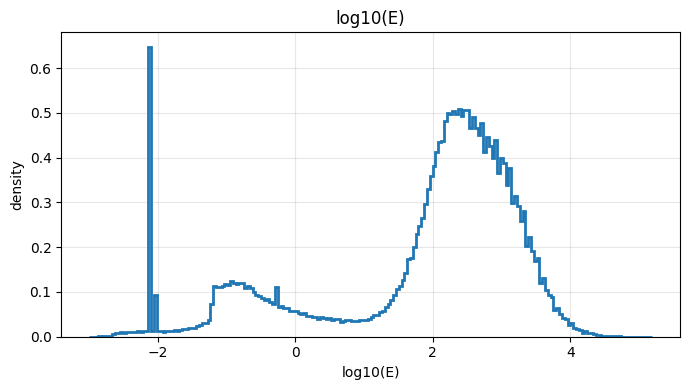

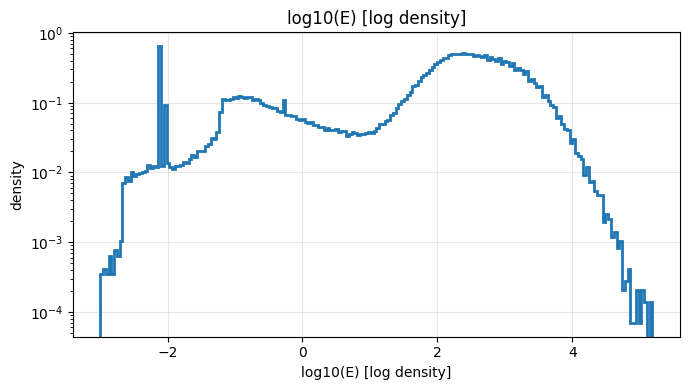

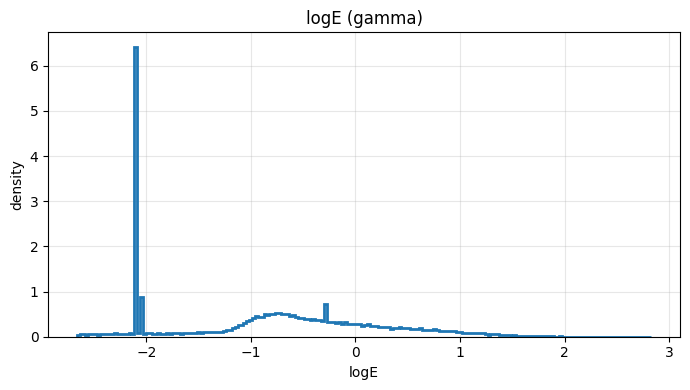

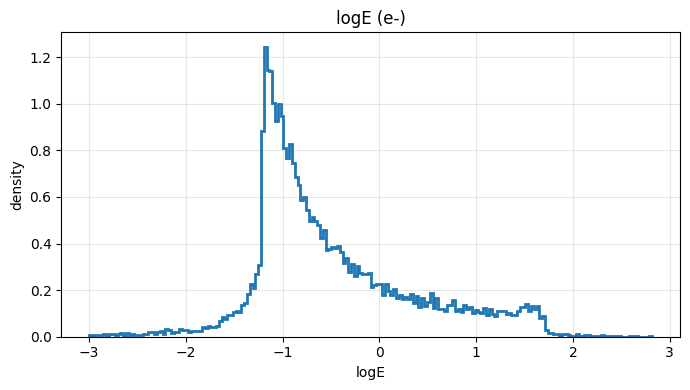

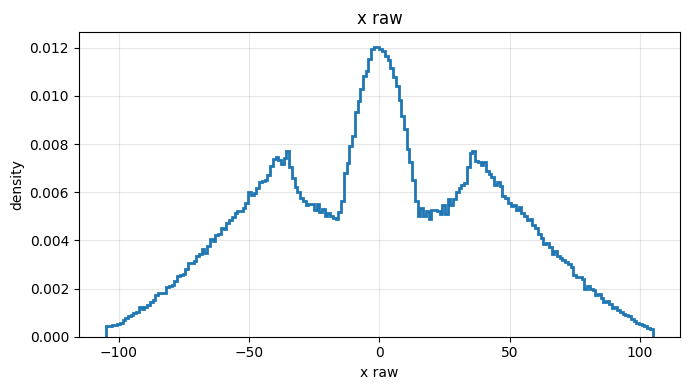

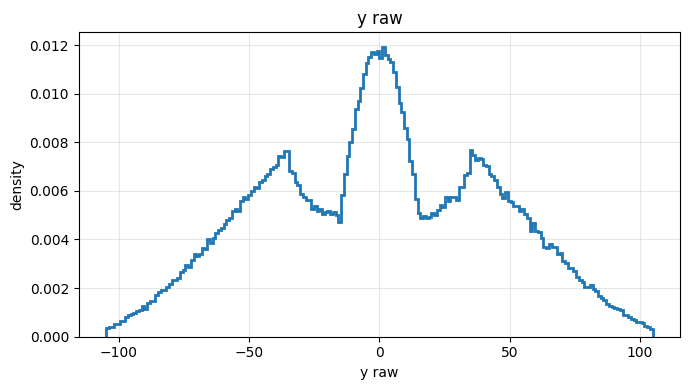

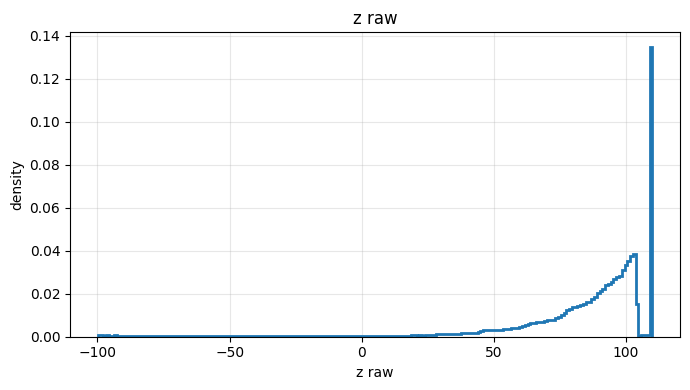

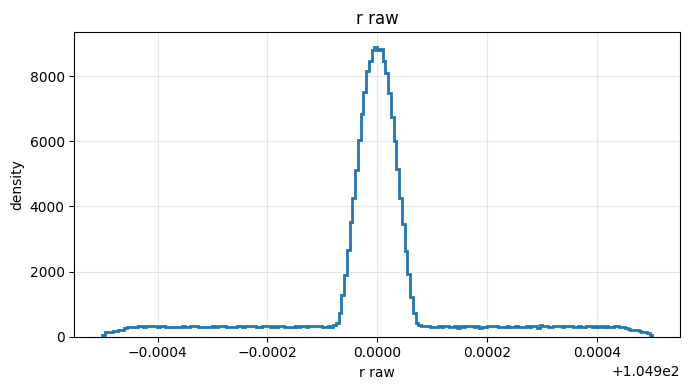

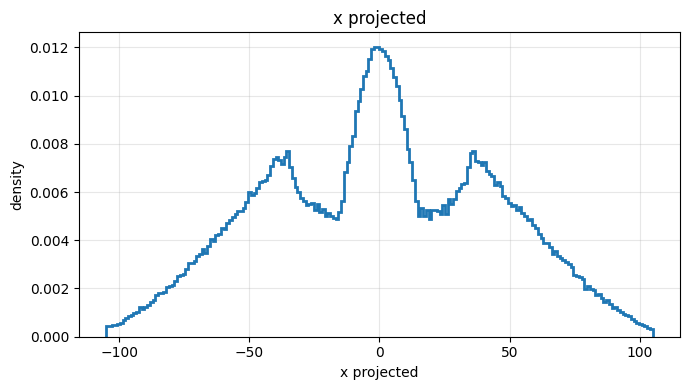

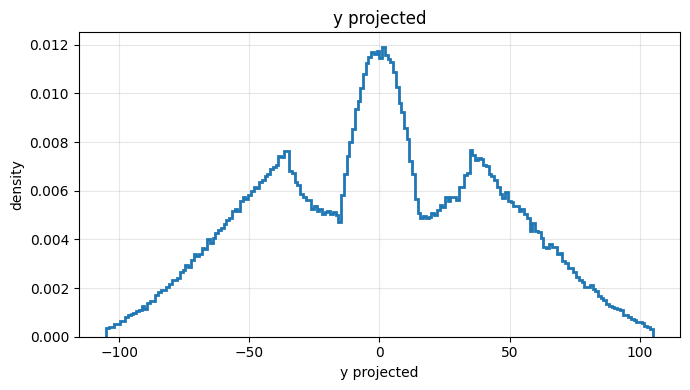

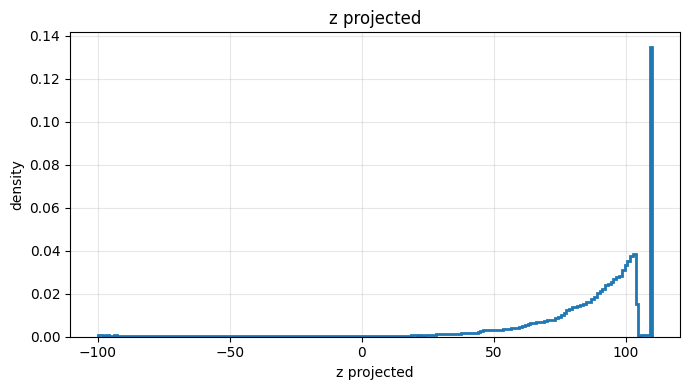

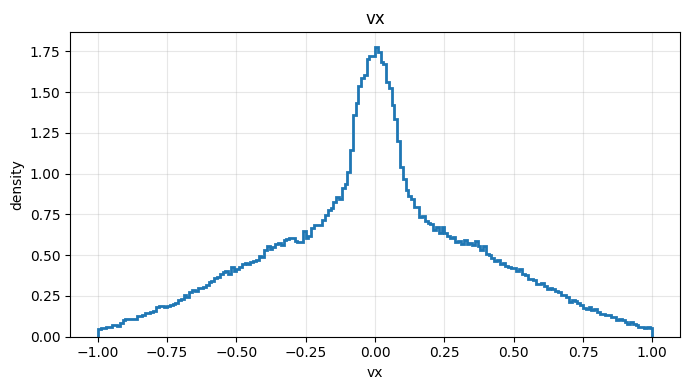

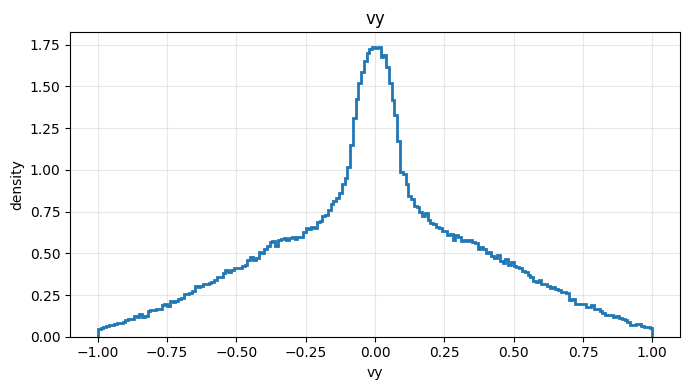

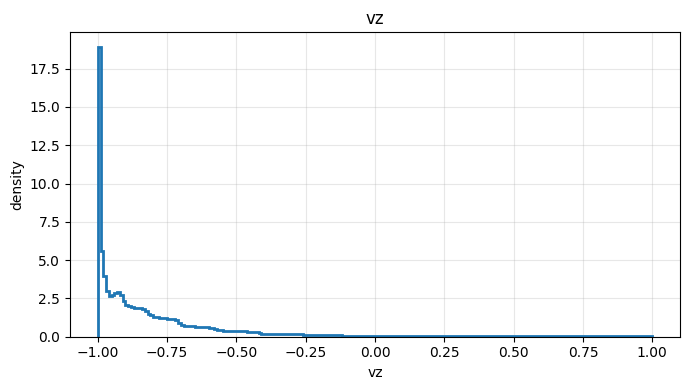

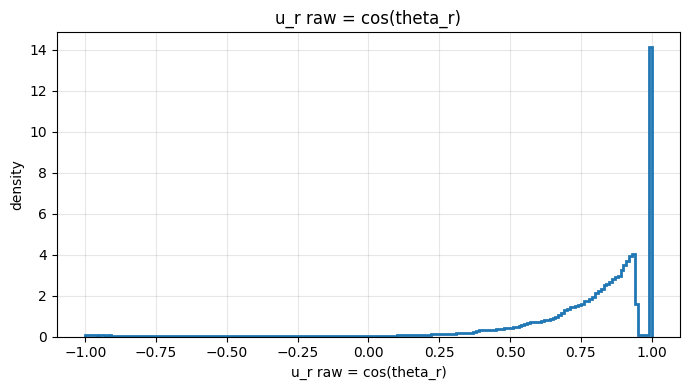

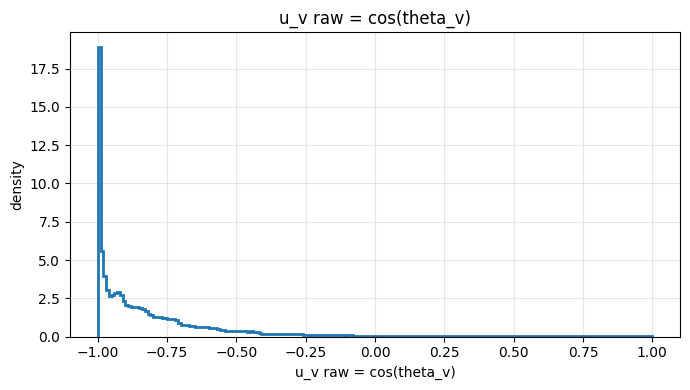

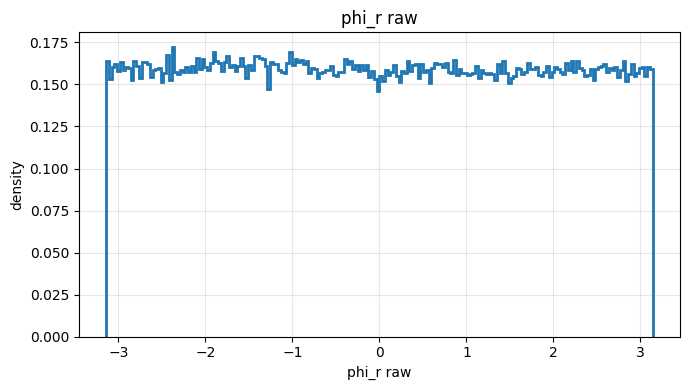

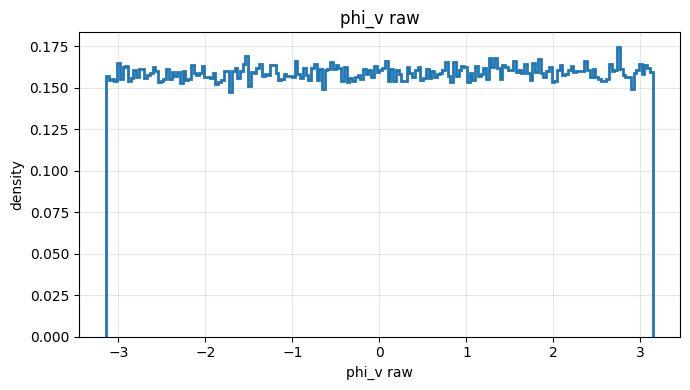

In [4]:
# ==========================================================
# Energy diagnostics from base physical features
# The v0.8 energy head models y = log10(E) directly (no binning), so the
# log-E shape below IS the target density the flow has to reproduce.
# ==========================================================

magi.plot_dist(feat_base["logE"], "log10(E)")
magi.plot_dist(feat_base["logE"], "log10(E) [log density]", yscale="log")
magi.plot_dist_by_class(feat_base, "logE", selected_class="gamma")
magi.plot_dist_by_class(feat_base, "logE", selected_class="e-")

# ==========================================================
# Raw / projected geometry
# ==========================================================

magi.plot_dist(raw["x"], "x raw")
magi.plot_dist(raw["y"], "y raw")
magi.plot_dist(raw["z"], "z raw")
magi.plot_dist(raw["r"], "r raw")

magi.plot_dist(proj["x"], "x projected")
magi.plot_dist(proj["y"], "y projected")
magi.plot_dist(proj["z"], "z projected")

magi.plot_dist(normdir["vx"], "vx")
magi.plot_dist(normdir["vy"], "vy")
magi.plot_dist(normdir["vz"], "vz")

# ==========================================================
# Raw physical geometry variables (unchanged from v0.7.2)
# ==========================================================

magi.plot_dist(feat_base["u_r"], "u_r raw = cos(theta_r)", range_=(-1, 1))
magi.plot_dist(feat_base["u_v"], "u_v raw = cos(theta_v)", range_=(-1, 1))
magi.plot_dist(feat_base["phi_r"], "phi_r raw", range_=(-np.pi, np.pi))
magi.plot_dist(feat_base["phi_v"], "phi_v raw", range_=(-np.pi, np.pi))

plt.show()

### Energy line detection

The mixture head is *told* where the lines are — their positions are fixed inputs
(`line_positions_y`), not learned — so getting them right matters more than any
tuning knob downstream. Detection matches statistically significant peaks against
the mass model's candidate table
(`CandidateLines/..._EADL.json`, built by
`tools/build_candidate_lines_from_geant4.py` from Geant4's own databases: the
atomic-relaxation tables for every element in the GDML mass model, and
PhotonEvaporation5.2 for the K-40 / Ra-226 / Th-232 / Rn-222 decay lines — no
values hand-typed from outside literature).

Three v0.8.1 corrections apply here:

- **EADL energies.** The table now takes its energies from `G4EMLOW7.3/fluor`
  (what Geant4 emits by default) while keeping the transition *labels* from
  `fluor_Bearden` (the only directory that ships them). The two differ by 17–43 eV
  — 4–11 detector FWHM — and the measured peaks match EADL to <1 eV.
- **Closest-pair matching.** Candidates used to claim peaks in JSON list order, so
  CR's ~8.0 keV Cu Kα peak was taken by Ni Kβ, 194 eV away, and modelled under the
  wrong label.
- **Sub-bin peak refinement** (`refine_bin_width_mev`). A detection bin is ~166 eV
  wide at 8 keV and ~21 keV at 511 keV on CR's log grid, so its centre is not a
  usable line position — without refinement the 511 keV peak matches Po-218.

Expected: instrumental fluorescence lines appear as `matched_lines`; the source
decay lines mostly appear as `unmatched_candidates`, since the sources sit in bulk
shielding and their primary gammas are Compton-degraded before crossing the
CryoSphere.

In [5]:
CANDIDATE_LINES_FILE = (
    "/path/to/MAGI/CandidateLines/"
    # DM1.2 mass model: different GDML/materials near the detector than the
    # SRON CCN cryostat, so its own candidate-line table with escape peaks
    # (built via tools/build_candidate_lines_from_geant4.py).
    "CANDIDATE_ENERGY_LINES_CriostatoDM1_2_Richiesta11_06_2026-worldVOL_EADL_escape.json"
)

candidate_payload = magi.load_candidate_energy_lines(CANDIDATE_LINES_FILE)
candidate_lines = candidate_payload["lines"]

print(f"Loaded {candidate_payload['n_lines']} candidate lines "
      f"for mass model: {candidate_payload['mass_model']}")
print("Sources covered:", candidate_payload["sources"])


Loaded 132 candidate lines for mass model: CriostatoDM1_2_Richiesta11_06_2026-worldVOL.gdml
Sources covered: ['K-40', 'Ra-226 chain', 'Rn-222 chain', 'Th-232 chain']


In [6]:
line_result = magi.detect_energy_lines(
    E_all,
    binning_mode="log_fixed_count",
    n_bins=1024,
    prominence_factor=3.0,
    window=5,
    candidate_lines=candidate_lines,
    # Refine each detected peak to the pinned line width before matching:
    # a detection bin is ~166 eV wide at 8 keV and ~21 keV at 511 keV on
    # CR's log grid, so its centre is not a usable line position.
    refine_bin_width_mev=X_IFU_RESOLUTION_EV * 1e-6,
)

magi.print_detected_energy_lines(line_result)

# Weak matches (single- to double-digit real counts out of millions of events)
# are filtered out before they feed the mixture head: a line slot the gate can
# never populate reliably only adds a spurious mixture component. Phase A above
# still reports every statistical match, for transparency; this filter is
# layered on top, here, not inside detect_energy_lines.
matched_all = line_result["matched_lines"]
matched = [m for m in matched_all if m["count"] >= 100]
dropped = [m for m in matched_all if m["count"] < 100]

print(f"\n{len(matched_all)} matched lines; {len(matched)} feed the mixture head "
      f"(count>=100): {[m['label'] for m in matched]}")
if dropped:
    print(f"  dropped as too weak (count<100): "
          f"{[(m['label'], int(m['count'])) for m in dropped]}")


--- Energy line detection ---
events: 353026  bins: 1024  mode: log_fixed_count
candidate lines: 132  detected peaks: 4  matched: 3

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.510999 MeV detected=0.510999 MeV delta=-0.000000 MeV  count=771
  Cu K-alpha1          (instrumental          ) expected=0.008006 MeV detected=0.008006 MeV delta=-0.000000 MeV  count=9213
  Cu K-beta            (instrumental          ) expected=0.008865 MeV detected=0.008865 MeV delta=-0.000001 MeV  count=1221

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Al K-alpha1          (instrumental          ) expected=0.001469 MeV
  Al K-alpha2          (instrumental          ) expected=0.001469 MeV
  Al K-beta            (instrumental          ) expected=0.001545 MeV
  Si K-alpha1          (instrumental          ) expected=0.001721 MeV
  Si K-alpha2          (instrumental          ) expected=0.001720 MeV
  Si K-beta            (instrumental          ) e

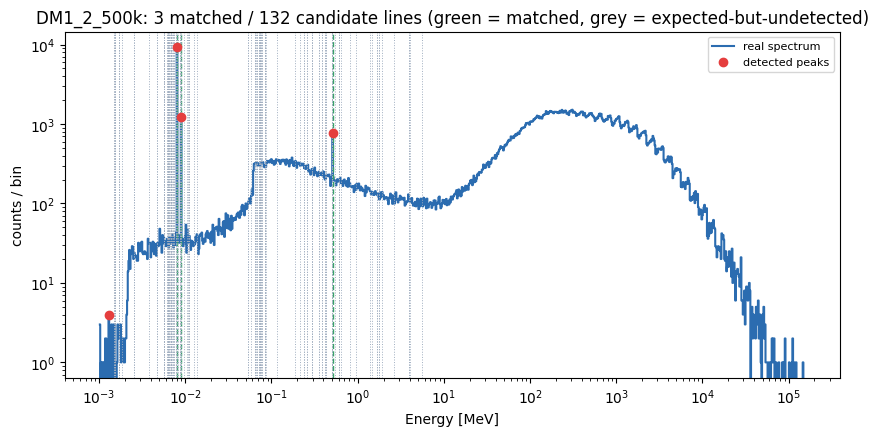

In [7]:
def plot_line_detection(name, E, result):
    edges = np.asarray(result["energy_bins"])
    centres = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(E, bins=edges)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.step(centres, counts, where="mid", color="#2b6cb0", label="real spectrum")

    for m in result["matched_lines"]:
        ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=1, ls="--")
    for c in result["unmatched_candidates"]:
        ax.axvline(c["candidate_energy_mev"], color="#a0aec0", lw=0.7, ls=":")

    peak_e = [p["energy_mev"] for p in result["detected_peaks"]]
    peak_c = [p["count"] for p in result["detected_peaks"]]
    ax.scatter(peak_e, peak_c, color="#e53e3e", zorder=5, label="detected peaks")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("counts / bin")
    ax.set_title(
        f"{name}: {result['n_matched']} matched / {result['n_candidate_lines']} "
        "candidate lines (green = matched, grey = expected-but-undetected)"
    )
    ax.legend(fontsize=8)
    plt.show()


plot_line_detection(SOURCE, E_all, line_result)

## Line-position audit (v0.8.1)

Before training anything, check the one input the mixture head cannot recover from:
**is each pinned line actually where the real events are?** With 4 eV widths, a line
misplaced by more than ~1 FWHM produces a generated peak that does not overlap the
real one at all — and the old bin-width recovery window was far too wide to notice.

This measures each matched line directly from the raw events at eV resolution:
centroid, width, line and continuum counts, and the offset from the catalogue value
in units of the pinned FWHM. Same computation as `tools/line_centroid_audit.py`.

In [8]:
FWHM_MEV = X_IFU_RESOLUTION_EV * 1e-6
SIGMA_MEV = FWHM_MEV / 2.3548200450309493

E_sorted = np.sort(E_all)


def audit_line(E_c, label, search_fwhm=20.0, fail_fwhm=1.0):
    """Measure the real peak near E_c: centroid, width, line/continuum split."""
    half = search_fwhm * FWHM_MEV
    lo, hi = E_c - half, E_c + half
    i0, i1 = np.searchsorted(E_sorted, [lo, hi])
    sub = E_sorted[i0:i1]
    if sub.size < 10:
        return {"label": label, "verdict": "absent"}

    step = FWHM_MEV / 2.0
    nb = max(int(round((hi - lo) / step)), 8)
    hist, edges = np.histogram(sub, bins=nb, range=(lo, hi))
    med = float(np.median(hist))
    k = int(np.argmax(hist))
    if hist[k] < max(10.0, 5.0 * max(med, 1.0)):
        return {"label": label, "verdict": "absent"}

    thr = max(med * 2.0, 1.0)
    a = b = k
    while a > 0 and hist[a - 1] > thr:
        a -= 1
    while b < nb - 1 and hist[b + 1] > thr:
        b += 1
    core = sub[(sub >= edges[a]) & (sub < edges[b + 1])]
    n_cont = med * (b - a + 1)
    centroid = float(core.mean())
    std = float(core.std(ddof=1)) if core.size > 1 else 0.0
    delta = E_c - centroid
    return {
        "label": label, "verdict": "ok",
        "catalogue_keV": E_c * 1e3,
        "measured_keV": centroid * 1e3,
        "delta_eV": delta * 1e6,
        "delta_FWHM": abs(delta) / FWHM_MEV,
        "measured_FWHM_eV": std * 2.3548200450309493 * 1e6,
        "n_line": max(core.size - n_cont, 0.0),
        "pass": abs(delta) / FWHM_MEV <= fail_fwhm,
    }


audit = [audit_line(float(m["candidate_energy_mev"]), m["label"]) for m in matched]
audit_df = pd.DataFrame(audit)
print(f"{SOURCE}: line-position audit against the pinned {X_IFU_RESOLUTION_EV} eV FWHM\n")
print(audit_df.to_string(index=False))

bad = [a for a in audit if a["verdict"] != "ok" or not a["pass"]]
if bad:
    print(f"\n*** {len(bad)} line(s) are pinned more than 1 FWHM from their real peak - "
          f"the mixture head cannot reproduce them. Fix the candidate table before "
          f"training. ***")
else:
    print(f"\nAll {len(audit)} lines are within 1 FWHM of their measured position.")

DM1_2_500k: line-position audit against the pinned 4.0 eV FWHM

            label verdict  catalogue_keV  measured_keV     delta_eV   delta_FWHM  measured_FWHM_eV  n_line  pass
e+e- annihilation      ok      510.99900     510.99900 0.000000e+00 0.000000e+00      0.000000e+00   560.0  True
      Cu K-alpha1      ok        8.00571       8.00571 1.734723e-12 4.336809e-13      4.085301e-12  6023.0  True
        Cu K-beta      ok        8.86534       8.86534 0.000000e+00 0.000000e+00      0.000000e+00   815.0  True

All 3 lines are within 1 FWHM of their measured position.


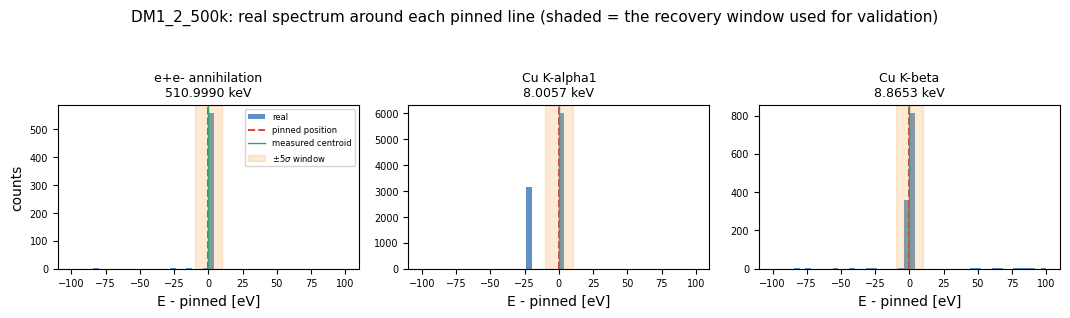

In [9]:
# Visual proof at line scale: the real spectrum in a +/-25 FWHM window around each
# line, with the pinned position marked. (With the Bearden table these markers sat
# 4-11 FWHM off the peak - visible here as a marker beside an empty bin.)

n_ax = len(matched)
fig, axes = plt.subplots(1, n_ax, figsize=(3.6 * n_ax, 3.2))
axes = np.atleast_1d(axes)
for ax, m, a in zip(axes, matched, audit):
    E_c = float(m["candidate_energy_mev"])
    half = 25 * FWHM_MEV
    sel = E_all[(E_all >= E_c - half) & (E_all <= E_c + half)]
    ax.hist((sel - E_c) * 1e6, bins=50, range=(-half * 1e6, half * 1e6),
            color="#2b6cb0", histtype="stepfilled", alpha=0.75, label="real")
    ax.axvline(0.0, color="#e53e3e", lw=1.4, ls="--", label="pinned position")
    if a["verdict"] == "ok":
        ax.axvline(-a["delta_eV"], color="#38a169", lw=1.0, label="measured centroid")
    ax.axvspan(-2.5 * X_IFU_RESOLUTION_EV, 2.5 * X_IFU_RESOLUTION_EV,
               color="#f6ad55", alpha=0.25, label=r"$\pm 5\sigma$ window")
    ax.set_title(f"{m['label']}\n{E_c*1e3:.4f} keV", fontsize=9)
    ax.set_xlabel("E - pinned [eV]")
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("counts")
axes[0].legend(fontsize=6)
fig.suptitle(f"{SOURCE}: real spectrum around each pinned line "
             f"(shaded = the recovery window used for validation)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Standardization and Preprocessing

Same pipeline as v0.7.2 — `build_feature_dataframe` → `filter_particle_types_
continuous_geometry` → `split_feature_data` → `scale_continuous_features` →
`build_conditioning_and_weights` → `build_tf_datasets` — with three additions:

1. `energy_transform="log10"`: energy enters as the continuous column
   `energy_y = log10(E)` rather than a bin index.
2. **Gate targets** labelling each event continuum-or-line, now with a
   **resolution-driven bandwidth** (v0.8.1, defect D).
3. **CDF warp knots** for the continuum flow.

In [10]:
feature_pack = magi.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    n_bins=512,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=10000,
    random_state=42,
    # v0.8: continuous energy target y = log10(E) alongside the bin index
    energy_transform="log10",
)
del prep  # superseded by feature_pack["filtered_prep"] from here on - the
# raw/proj/normdir/derived/feat_base aliases from cell 4 stay valid, they
# reference prep's underlying arrays directly, not the prep dict itself.

magi.report_feature_dataframe(feature_pack)

energy_bins = feature_pack["energy_bins"]
n_energy_bins = feature_pack["n_energy_bins"]

quantile_transformers = feature_pack["quantile_transformers"]
qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

geometry_metadata = feature_pack["geometry_metadata"]

print("Feature columns:", feature_pack["feat"].columns.tolist())
print("Geometry metadata:", geometry_metadata)


feat shape: (353026, 8)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  energy_y  \
0          mu-    370 -1.123562  1.016978 -0.643113  0.675588  2.923797   
1          mu-    332  0.405824 -0.133330  0.254986 -0.939178  2.321080   
2          mu-    322 -0.129351 -0.090693  0.424745 -0.903152  2.151835   
3          mu-    327 -0.059105  0.559271 -0.476832  0.879412  2.238916   
4          mu-    320 -0.029509  0.088489 -0.664348  0.762322  2.132858   

   PrimBool  
0         1  
1         1  
2         1  
3         1  
4         1  

--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  511
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393
  energy_y : -2.9957387447357178  5.188039302825928
  PrimBool : 0  1

--- Quantile geo

In [11]:
# ==========================================================
# v0.8.1 line inputs + gate targets
#
# The gate-target bandwidth is now set by the PINNED LINE WIDTH, not by the
# detection bin width. The bin-width bandwidth was +/-125 eV at 1.49 keV,
# +/-320 eV at 8.9 keV and +/-43 keV at 511 keV - 31 to 10,000 detector FWHM -
# so every event in that neighbourhood was labelled a line event and the gate was
# supervised to over-route by roughly that ratio. That is the mechanism behind
# v0.8's 5.8x over-generated 511 line and the continuum holes beside the lines.
# ==========================================================

line_positions_mev = np.array([m["candidate_energy_mev"] for m in matched], dtype=np.float64)
line_positions_y = np.log10(line_positions_mev).astype(np.float32)

E_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()

# v0.8.2 follow-up: bandwidth_mode="exact" (exact energy match, since raw
# Geant4 data has no detector response and lines are truly monoenergetic) was
# tried and REJECTED - measured on CR it left Cu Kalpha1 unchanged and broke
# both the Al Kalpha1 fix below and the coupling bar (docs/v0.8.1_line_truth.md
# section 14.2). "resolution" remains the default.
gate_targets = magi.build_gate_targets(
    E_full,
    feature_pack["energy_bins"],
    matched,
    bandwidth_mode="resolution",          # v0.8.1, confirmed again in v0.8.2
    bandwidth_fwhm_mev=FWHM_MEV,
)

# Legacy targets, for the diagnostic below only
gate_targets_bins = magi.build_gate_targets(E_full, feature_pack["energy_bins"], matched)

feat = feature_pack["feat"].copy()
for j in range(gate_targets.shape[1]):
    feat[f"gate_target_{j}"] = gate_targets[:, j]

cont_cols = ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q", "energy_y") + tuple(
    f"gate_target_{j}" for j in range(gate_targets.shape[1])
)

# How much of the data each mode labels as a line, against the truth measured in
# the audit above. 1.0 = the gate is asked to route exactly the real line rate.
print(f"{SOURCE}: gate-target line mass vs the true line fraction\n")
print(f"  {'line':22s} {'true':>10s} {'bins mode':>12s} {'resolution':>12s}")
for j, (m, a) in enumerate(zip(matched, audit)):
    true_frac = (a["n_line"] / E_full.size) if a["verdict"] == "ok" else float("nan")
    f_bins = gate_targets_bins[:, j + 1].mean()
    f_res = gate_targets[:, j + 1].mean()
    print(f"  {m['label']:22s} {true_frac:10.5f} "
          f"{f_bins:9.5f} ({f_bins/true_frac:4.2f}x) "
          f"{f_res:9.5f} ({f_res/true_frac:4.2f}x)")
print(f"\ny_cont columns: {cont_cols}")
print(f"line_positions_y (log10 E): {line_positions_y}")

DM1_2_500k: gate-target line mass vs the true line fraction

  line                         true    bins mode   resolution
  e+e- annihilation         0.00159   0.00983 (6.20x)   0.00156 (0.98x)
  Cu K-alpha1               0.01706   0.02144 (1.26x)   0.01683 (0.99x)
  Cu K-beta                 0.00231   0.00595 (2.58x)   0.00327 (1.41x)

y_cont columns: ('u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3')
line_positions_y (log10 E): [-0.29157996 -2.0966     -2.0523045 ]


In [12]:
dataset_pack = magi.filter_particle_types_continuous_geometry(
    feat=feat,
    prob_threshold=1e-5,
    cont_cols=cont_cols,
)

magi.report_continuous_geometry_features(dataset_pack)



Dataset mode: continuous_geometry
Continuous geometry version: custom_continuous_geometry
Kept particle types: 4
Types: ['mu-', 'gamma', 'e-', 'e+']

Empirical probabilities:
         mu-  p=7.808660e-01
       gamma  p=1.492553e-01
          e-  p=6.955578e-02
          e+  p=3.229224e-04

Shapes:
X_cont_raw: (353026, 9)
E_idx     : (353026,)
y_type    : (353026,)

--- Continuous feature ranges ---
   u_r_q : -5.199337482452393  5.199337482452393
   u_v_q : -5.199337482452393  5.199337482452393
 phi_r_q : -5.199337482452393  5.199337482452393
 phi_v_q : -5.199337482452393  5.199337482452393
energy_y : -2.9957387447357178  5.188039302825928
gate_target_0 : 0.019607843831181526  1.0
gate_target_1 : 0.0  0.9803921580314636
gate_target_2 : 0.0  0.9803921580314636
gate_target_3 : 0.0  0.9803921580314636

--- Continuous means/std ---
   u_r_q : mean= 0.005387  std= 0.996456
   u_v_q : mean=-0.019005  std= 0.988954
 phi_r_q : mean= 0.009844  std= 1.005586
 phi_v_q : mean=-0.011214  std= 0.99

In [13]:
# ==========================================================
# v0.8.2 Phase C candidate 1: per-type zone probabilities
#
# The learned prior p(z|cond) is trained on z ~ q(z|x), where the real event's
# gate-target columns are visible, but generation draws z ~ p(z|cond) with NO
# real event to read the zone from. prior_zone_conditioning widens cond from
# [type] to [type, zone] at TRAIN time (the real gate target); at GENERATION
# time the zone is instead sampled from each type's empirical zone frequency
# computed here. Confirmed on CR, 3 seeds: CR Al Kalpha1 recovery
# 0.702+/-0.290 (FAIL) -> 0.959+/-0.025 (PASS), coupling unaffected
# (docs/v0.8.1_line_truth.md section 14). Computed unconditionally - it is
# cheap, and this is the first v0.8.2 measurement of it on a non-CR source.
# ==========================================================

n_zones = gate_targets.shape[1]
zone_cols = dataset_pack["X_cont_raw"][:, -n_zones:]
y_type_for_zones = dataset_pack["y_type"]

zone_probs = np.zeros((dataset_pack["n_types"], n_zones), dtype=np.float64)
for t in range(dataset_pack["n_types"]):
    mask = (y_type_for_zones == t)
    row = zone_cols[mask].mean(axis=0) if mask.any() else np.zeros(n_zones)
    row_sum = row.sum()
    zone_probs[t] = (row / row_sum) if row_sum > 0 else np.eye(n_zones)[0]

zone_labels = ["continuum"] + [m["label"] for m in matched]
print(f"{SOURCE}: zone_probs (per type, {zone_labels}):")
for t, tname in dataset_pack["idx_to_type"].items():
    print(f"    {tname:12s} {np.round(zone_probs[t], 4)}")


DM1_2_500k: zone_probs (per type, ['continuum', 'e+e- annihilation', 'Cu K-alpha1', 'Cu K-beta']):
    mu-          [1. 0. 0. 0.]
    gamma        [0.855  0.0104 0.1127 0.0219]
    e-           [0.9999 0.     0.     0.    ]
    e+           [1. 0. 0. 0.]


Train: (247118, 9) Val: (52954, 9) Test: (52954, 9)

Type distribution check:
Train: [7.80865821e-01 1.49256630e-01 6.95538164e-02 3.23731982e-04]
Val  : [7.80866412e-01 1.49261623e-01 6.95509310e-02 3.21033350e-04]
Test : [7.80866412e-01 1.49242739e-01 6.95698153e-02 3.21033350e-04]
No StandardScaler applied.
scale_cols: ()

--- Train continuous means/std ---
     u_r_q: mean= 0.005216  std= 0.995165
     u_v_q: mean=-0.018998  std= 0.988419
   phi_r_q: mean= 0.011431  std= 1.005416
   phi_v_q: mean=-0.011611  std= 0.996989
  energy_y: mean= 1.857215  std= 1.511042
gate_target_0: mean= 0.978464  std= 0.143380
gate_target_1: mean= 0.001522  std= 0.038589
gate_target_2: mean= 0.016749  std= 0.126696
gate_target_3: mean= 0.003265  std= 0.056455

cond_train shape: (247118, 4)
cond_val shape  : (52954, 4)
cond_test shape : (52954, 4)

Example one-hot rows:
tf.Tensor(
[[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]], shape=(5, 4), dtype=float32)

Class fractions i


Datasets ready.
Dataset mode: continuous_geometry
Train batches: 61
Val batches  : 13
Test batches : 13



Batch check:
X_cont batch shape: (4096, 9)
E_idx batch shape : (4096,)
cond batch shape  : (4096, 4)
Energy binning mode: log_fixed_count
Number of energy bins: 512

Energy train min/max:
0.00100986 145913.0

First bin: 0.0010098599999999998 0.001047719705156385
Last bin : 148612.50912214027 154183.99999999994

Bin width summary:
min width : 3.785970515638522e-05
max width : 5571.490877859673
mean width: 301.14062302761704

--- Energy bin occupancy check ---
min counts: 0
max counts: 6474
mean counts: 482.65234375
empty bins: 17
empty bin fraction: 0.033203125

--- Log-fixed-count mode diagnostics ---
Requested bins: 512
log10(E) min/max: -2.9957388296250826 5.164093986730683
log-bin width min : 0.01598394167582029
log-bin width max : 0.015983941675822955
log-bin width mean: 0.015983941675821678


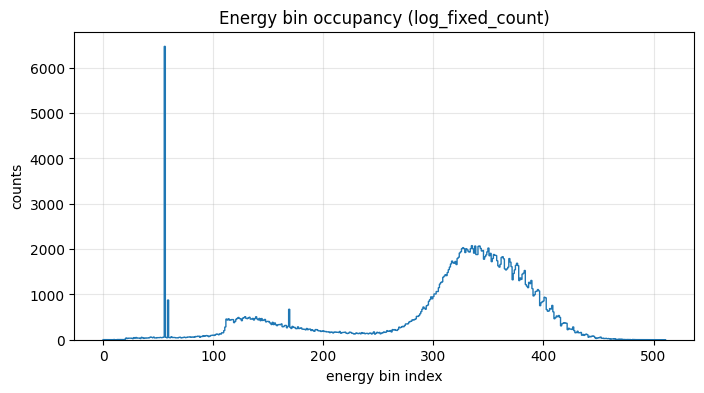

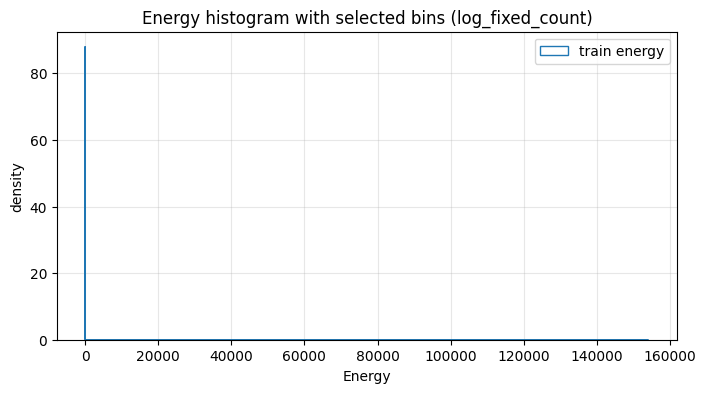

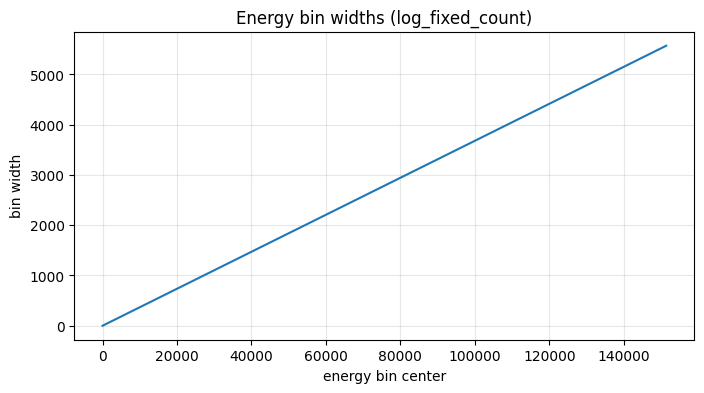

In [14]:
split_pack = magi.split_feature_data(
    dataset_pack,
    test_size_total=0.30,
    val_size_from_temp=0.50,
    random_state=42,
)

magi.report_split_summary(split_pack, n_types=dataset_pack["n_types"])

scaled_pack = magi.scale_continuous_features(
    split_pack,
    scale_cols=(),
)

magi.report_scaled_features(scaled_pack)

condition_pack = magi.build_conditioning_and_weights(
    scaled_pack,
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    alpha=0.5,
)

magi.report_conditioning(condition_pack, n_types=dataset_pack["n_types"])

tf_pack = magi.build_tf_datasets(
    condition_pack,
    batch_size=4096,
    shuffle_buffer_cap=200_000,
)

magi.report_tf_datasets(tf_pack)

magi.report_energy_binning_diagnostics(
    energy_bins=feature_pack["energy_bins"],
    E_idx=dataset_pack["E_idx"],
    E_values=feature_pack["filtered_prep"]["features"]["Energy"].to_numpy(),
    idx_train=split_pack["idx_train"],
    energy_binning_mode=feature_pack["energy_config"]["mode"],
    bin_width=feature_pack["energy_config"]["bin_width"],
    n_bins=feature_pack["energy_config"]["n_bins"],
    min_counts=feature_pack["energy_config"]["min_counts"],
)

In [15]:
# ==========================================================
# Recover all main objects from package outputs - v0.8
# ==========================================================

feat = dataset_pack["feat"]

# model-side continuous block: [u_r_q, u_v_q, phi_r_q, phi_v_q, energy_y, gate_*]
X_cont_train_s = tf_pack["X_cont_train_s"]
X_cont_val_s = tf_pack["X_cont_val_s"]
X_cont_test_s = tf_pack["X_cont_test_s"]

X_cont_train = tf_pack["X_cont_train"]
X_cont_val = tf_pack["X_cont_val"]
X_cont_test = tf_pack["X_cont_test"]

# energy bin indices: kept for diagnostics/validation only - the v0.8 head does
# NOT consume them (it reads energy_y, column 4 of X_cont).
E_train = tf_pack["E_train"]
E_val = tf_pack["E_val"]
E_test = tf_pack["E_test"]

cond_train = tf_pack["cond_train"]
cond_val = tf_pack["cond_val"]
cond_test = tf_pack["cond_test"]

train_ds = tf_pack["train_ds"]
val_ds = tf_pack["val_ds"]
test_ds = tf_pack["test_ds"]

type_weights = tf_pack["type_weights"]

n_types = dataset_pack["n_types"]
idx_to_type = dataset_pack["idx_to_type"]
type_probs = dataset_pack["type_probs"]

cont_cols = dataset_pack["cont_cols"]
Y_CONT_DIM = X_cont_train_s.shape[1]
N_LINES = int(len(matched))

# raw physical references, per split
features_filtered = feature_pack["filtered_prep"]["features"]

E_all_filtered = features_filtered["Energy"].to_numpy()
u_r_all_raw = features_filtered["u_r"].to_numpy()
u_v_all_raw = features_filtered["u_v"].to_numpy()
phi_r_all_raw = features_filtered["phi_r"].to_numpy()
phi_v_all_raw = features_filtered["phi_v"].to_numpy()

idx_train = split_pack["idx_train"]
idx_val = split_pack["idx_val"]
idx_test = split_pack["idx_test"]

E_train_raw = E_all_filtered[idx_train]
E_val_raw = E_all_filtered[idx_val]
E_test_raw = E_all_filtered[idx_test]

print("Y_CONT_DIM:", Y_CONT_DIM, "(4 geometry + 1 energy_y + %d gate slots)" % (N_LINES + 1))
print("cont_cols :", cont_cols)
print("n_types   :", n_types, idx_to_type)
print("n_lines   :", N_LINES)
print("Available quantile transformers:", list(quantile_transformers.keys()))

Y_CONT_DIM: 9 (4 geometry + 1 energy_y + 4 gate slots)
cont_cols : ['u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3']
n_types   : 4 {0: 'mu-', 1: 'gamma', 2: 'e-', 3: 'e+'}
n_lines   : 3
Available quantile transformers: ['qt_u_r', 'qt_u_v', 'qt_phi_r', 'qt_phi_v']


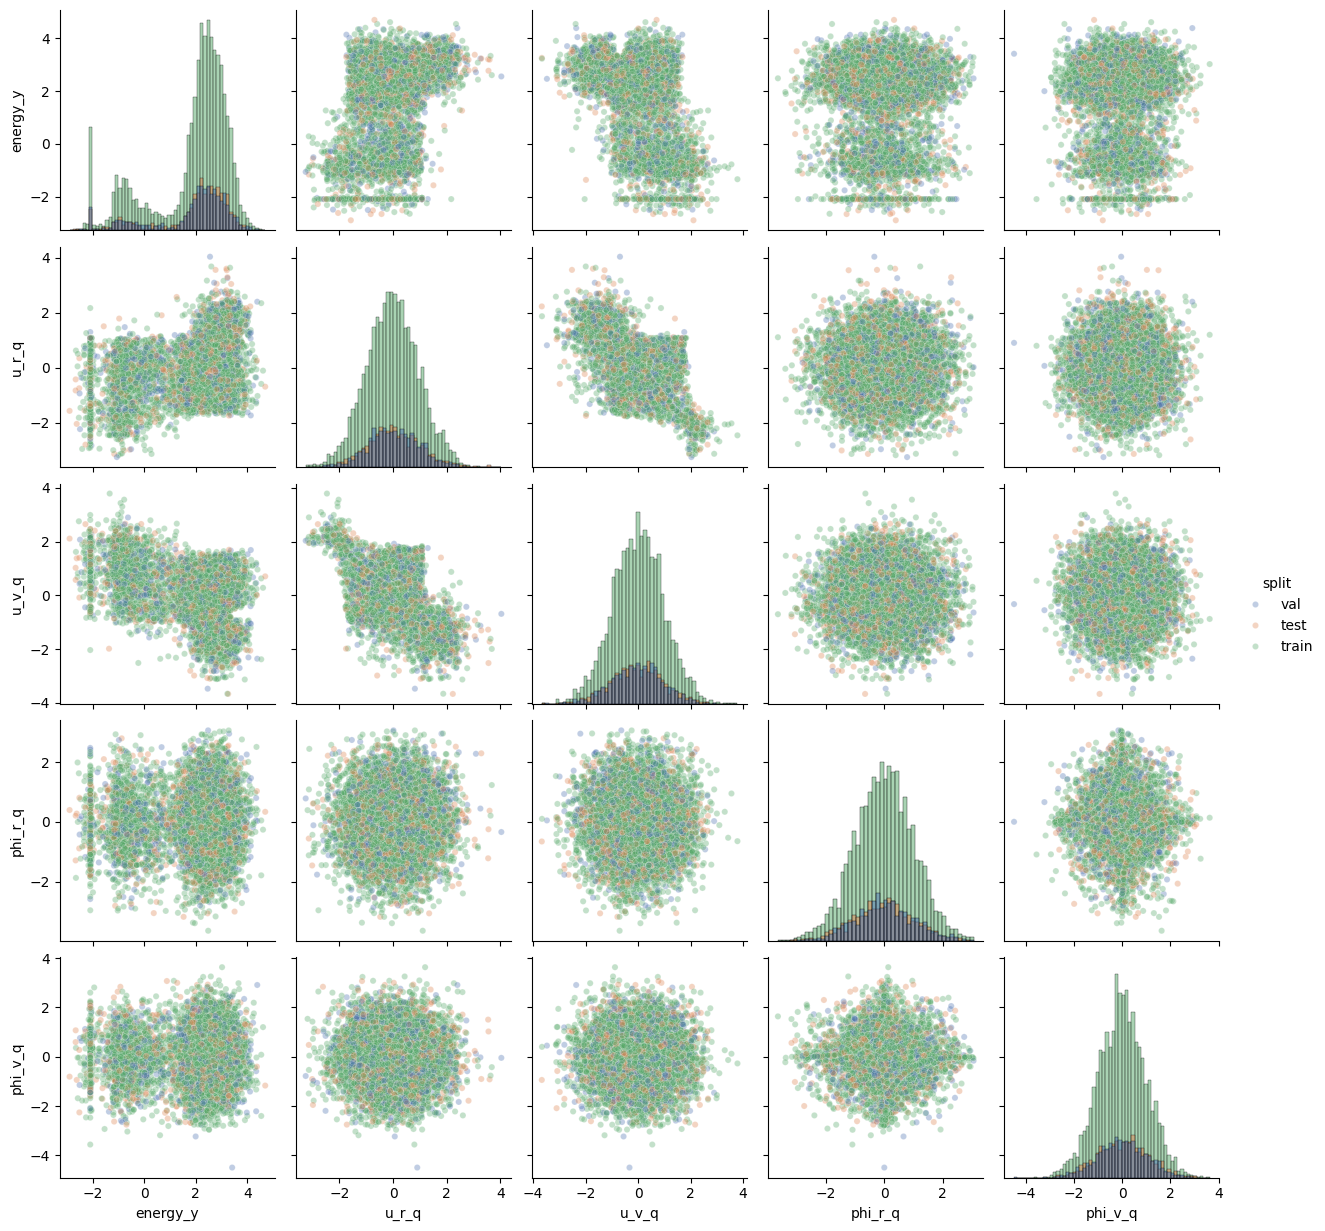

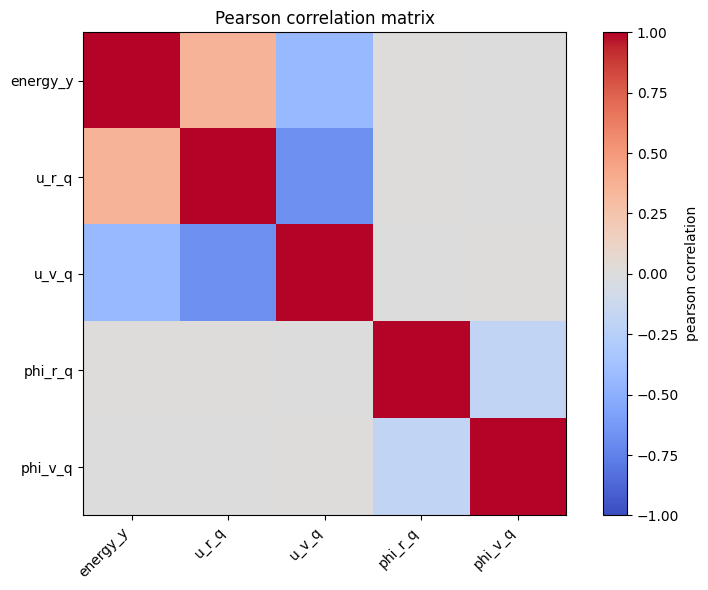

In [16]:
# ==========================================================
# Split sanity: the three splits must be statistically identical
# ==========================================================

df_train_plot = dataset_pack["feat"].iloc[split_pack["idx_train"]].copy()
df_val_plot   = dataset_pack["feat"].iloc[split_pack["idx_val"]].copy()
df_test_plot  = dataset_pack["feat"].iloc[split_pack["idx_test"]].copy()

df_train_plot["split"] = "train"
df_val_plot["split"]   = "val"
df_test_plot["split"]  = "test"

df_all_splits = pd.concat(
    [df_train_plot, df_val_plot, df_test_plot],
    axis=0,
    ignore_index=True,
)

model_space_cols = ["energy_y", "u_r_q", "u_v_q", "phi_r_q", "phi_v_q"]

magi.plot_pairwise_sample(
    df_all_splits,
    cols=model_space_cols,
    class_col="split",
    sample_size=8000,
)

magi.plot_correlation_matrix(
    df_all_splits,
    model_space_cols,
    method="pearson",
)

plt.show()

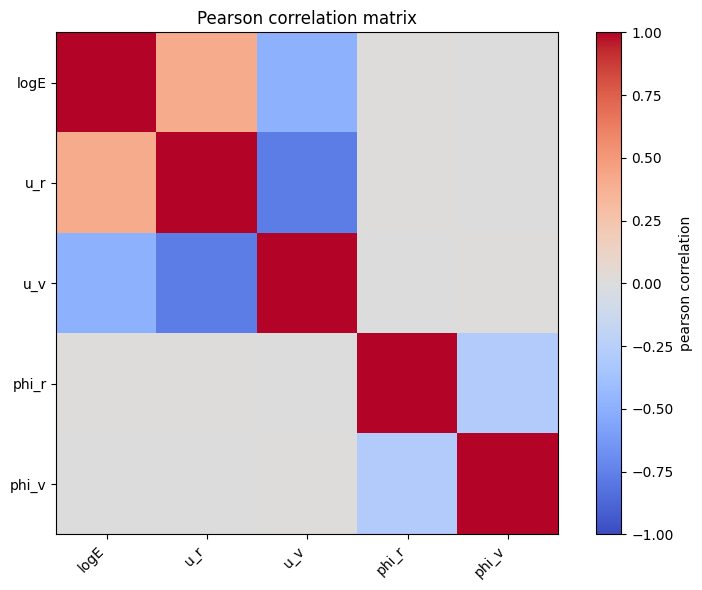

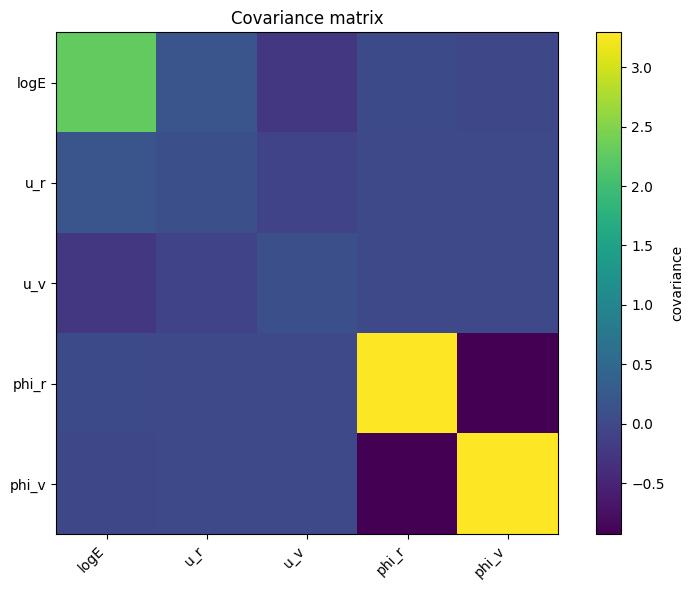

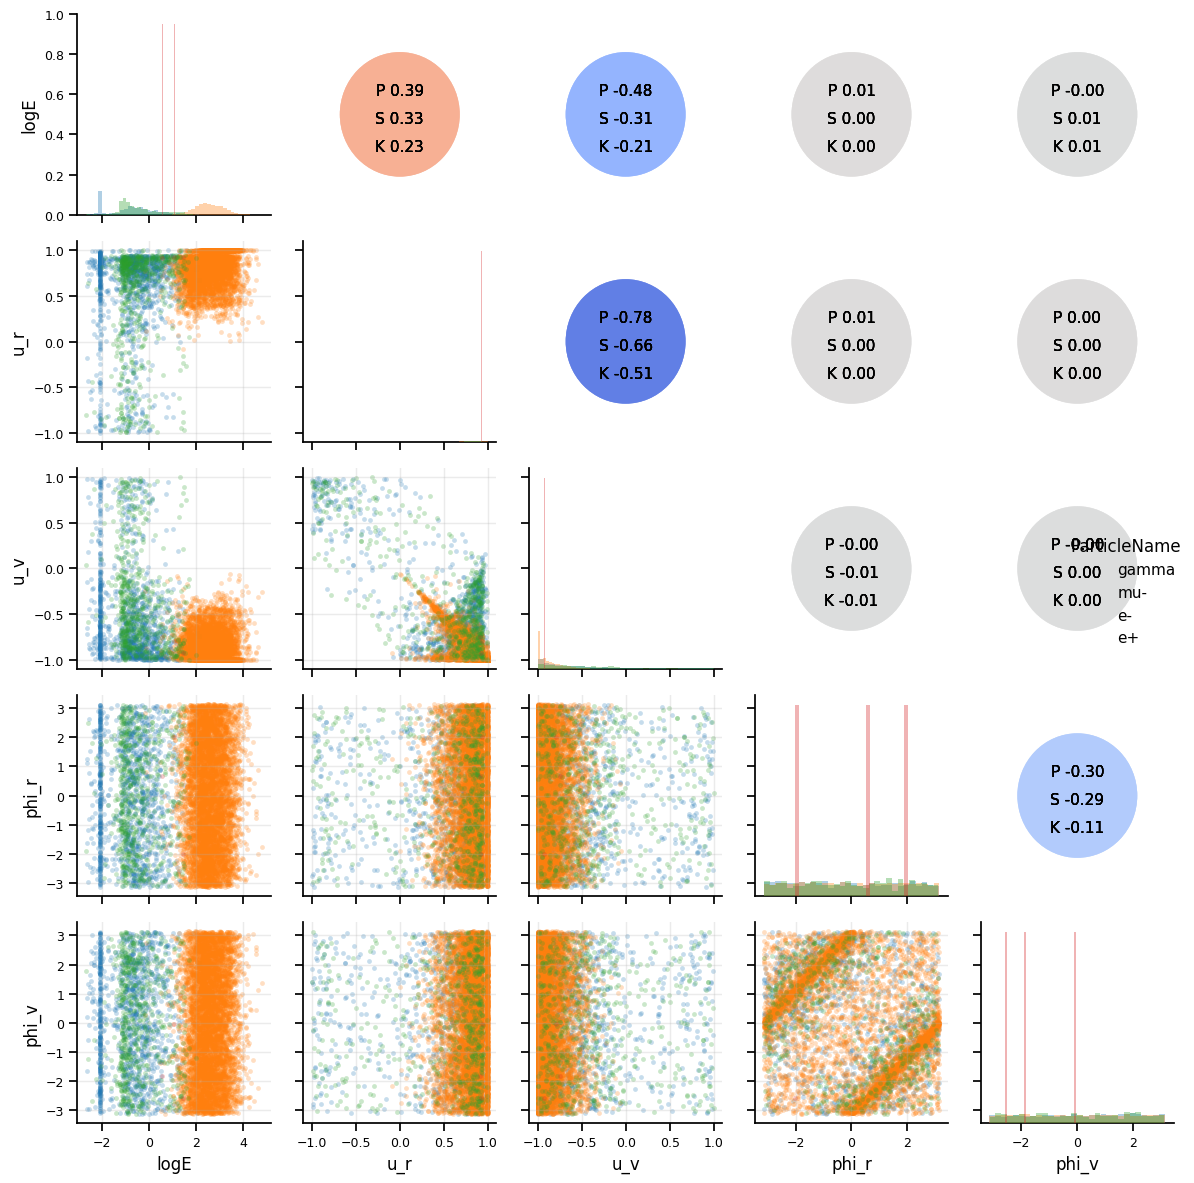

In [17]:
# ==========================================================
# Real-data structure the model has to reproduce: correlation, covariance and
# the full pairgrid over the physical variables. These are the reference for
# the identical plots on generated events in the validation section.
# ==========================================================

corr_df = feature_pack["filtered_prep"]["features"].copy()
corr_df["logE"] = np.log10(corr_df["Energy"].to_numpy())

corr_cols_phys = ["logE", "u_r", "u_v", "phi_r", "phi_v"]

corr_real = magi.plot_correlation_matrix(corr_df, corr_cols_phys, method="pearson")
cov_real = magi.plot_covariance_matrix(corr_df, corr_cols_phys)

magi.plot_pairgrid_physics(
    corr_df,
    cols=corr_cols_phys,
    class_col="ParticleName",
    sample_size=8000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
    theme="light",
    palette="tab10",
)

plt.show()

CDF warp: 256 knots over y in [-2.768, 4.712] -> z in [-3.72, 3.72]
affine reference (NOT used): y_mean=1.856 y_scale=1.510


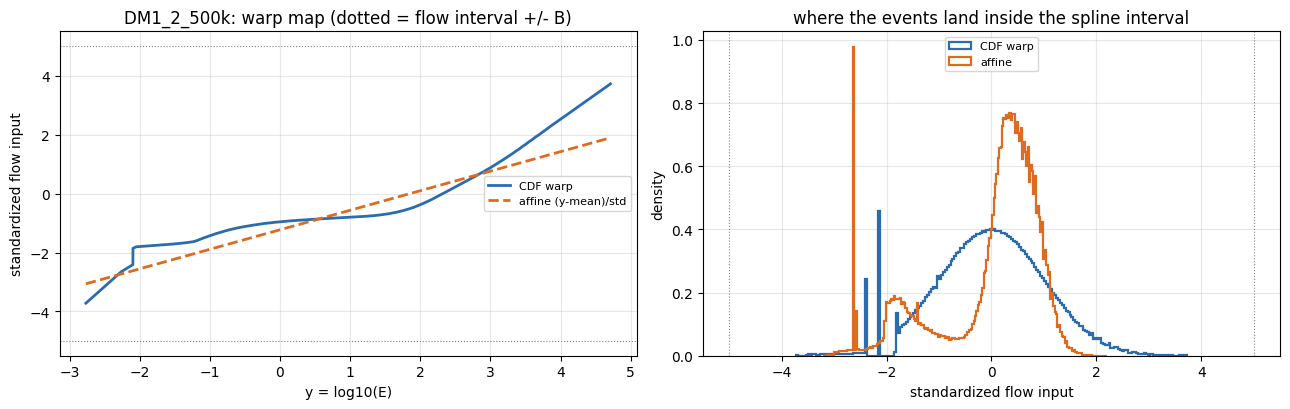

In [18]:
# ==========================================================
# CDF pre-warp knots for the flow continuum  (v0.8 Cycle 1)
#
# The RQS flow warps a FIXED interval [-B, B] (B = interval_half_width = 5) in
# standardized space, with frozen N(0,1) tails outside it. With plain affine
# standardization (y - mean)/std that interval is allocated by *variance*, not
# by where the events are:
#   - CR: the muon tail (to ~1e6 MeV) inflates the std, so the low-energy bulk
#     occupies a tiny slice of [-5, 5] and too few spline knots land on the
#     Compton edge -> it comes out over-smoothed.
#   - Small: the bulk is narrow, so the sparse low-energy tail lands near/beyond
#     B=5 -> the frozen normal tails take over and the tail density collapses.
#
# fit_cdf_warp_knots builds a monotone empirical-CDF -> N(0,1) map instead, so the
# knots are density-proportional: every quantile of the data gets comparable
# spline resolution and nothing falls outside the modelled interval. Validated on
# the --sparse-tail synthetic: deep-tail window ratio 0.00 (affine) -> 0.96 (cdf).
# See docs/v0.8_v072_comparison.md sec 6(b) and sec 9.
# ==========================================================

energy_y_all = feat["energy_y"].to_numpy()

warp_y_knots, warp_z_knots = magi.fit_cdf_warp_knots(
    energy_y_all,
    n_knots=256,
    eps=1e-4,
)

y_mean_affine = float(energy_y_all.mean())
y_scale_affine = float(energy_y_all.std())

print(f"CDF warp: {warp_y_knots.size} knots over "
      f"y in [{warp_y_knots[0]:.3f}, {warp_y_knots[-1]:.3f}] "
      f"-> z in [{warp_z_knots[0]:.2f}, {warp_z_knots[-1]:.2f}]")
print(f"affine reference (NOT used): y_mean={y_mean_affine:.3f} y_scale={y_scale_affine:.3f}")

# What the two standardizations do to the same data: the fraction of [-5, 5]
# that the physically interesting bulk actually occupies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(warp_y_knots, warp_z_knots, color="#2b6cb0", lw=2, label="CDF warp")
axes[0].plot(warp_y_knots, (warp_y_knots - y_mean_affine) / y_scale_affine,
             color="#dd6b20", lw=2, ls="--", label="affine (y-mean)/std")
axes[0].axhline(5, color="0.5", lw=0.8, ls=":")
axes[0].axhline(-5, color="0.5", lw=0.8, ls=":")
axes[0].set_xlabel("y = log10(E)")
axes[0].set_ylabel("standardized flow input")
axes[0].set_title(f"{SOURCE}: warp map (dotted = flow interval +/- B)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for lbl, z, c in [("CDF warp", np.interp(energy_y_all, warp_y_knots, warp_z_knots), "#2b6cb0"),
                  ("affine", (energy_y_all - y_mean_affine) / y_scale_affine, "#dd6b20")]:
    axes[1].hist(np.clip(z, -8, 8), bins=200, histtype="step", lw=1.6, color=c,
                 density=True, label=lbl)
axes[1].axvline(5, color="0.5", lw=0.8, ls=":")
axes[1].axvline(-5, color="0.5", lw=0.8, ls=":")
axes[1].set_xlabel("standardized flow input")
axes[1].set_ylabel("density")
axes[1].set_title("where the events land inside the spline interval")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Training with MAGI Package

### Model v0.8.2 `CVAE_MixEnergy_ContPhi_TaskAdaptive`

Architecture identical to v0.8 — flow continuum (24 bins, 3 transforms) with the CDF
pre-warp, fixed lines pinned to 4 eV FWHM, `energy_flow_condition="z_cond"` with the
learnable coupling prior `p(z|cond)`. Three configuration changes over v0.8:

- **Gate targets** from the resolution bandwidth (cell above), so the gate is
  supervised toward the true line rate instead of 3.5–4.6× it.
- **`gate_focal_gamma = 1`**, down from 2. The focal term exists to stop the ~99%
  continuum majority from dominating the gate cross-entropy; with the labels no
  longer inflated, γ=2 over-corrects. On the narrow-line synthetic
  (`tools/synthetic_stress_test_cr_multimodal.py --line-sigma-y 0.002
  --gate-bandwidth-mode resolution`), γ=1 gave line recoveries 1.05–1.57 against
  γ=2's 1.08–2.57, between-line continuum 0.97/0.81/0.59 against 0.43/0.16/0.30, and
  continuum core 0.807 against 0.655.

`gate_class_weights` (per-line manual weights) remains available and
checkpoint-safe as the next lever, and is left `None` here. If it is needed, the
update must be **two-sided** (`clip(w·(target/recovery)^α, 1/cap, cap)`) — the
failure mode is over-generation, which a floor of 1.0 cannot correct.

- **`prior_zone_conditioning=True`, `zone_probs`** (v0.8.2). Widens the coupling
  prior's conditioning from `[type]` to `[type, zone]`, using the `zone_probs`
  computed above. Confirmed on CR (3 seeds): CR Al Kα1 recovery
  0.702 ± 0.290 (FAIL) → **0.959 ± 0.025 (PASS)**, coupling unaffected. This is
  the run's first measurement of it on a source other than CR.

In [19]:
# ==========================================================
# Configuration for later saving and reference - v0.8.2
# ==========================================================

EPOCHS = 40
LEARNING_RATE = 2e-4

line_logsigma_init = magi.line_logsigma_from_resolution(
    line_positions_mev, X_IFU_RESOLUTION_EV, fwhm=True,
)

model_config = {
    "model_class": "CVAE_MixEnergy_ContPhi_TaskAdaptive",
    "n_types": n_types,
    "line_positions_y": line_positions_y.tolist(),

    "latent_dim": 8,
    "hidden": [128, 128, 64],
    "beta": 0.2,

    "continuum_mode": "flow",
    "continuum_flow_bins": 24,
    "continuum_flow_transforms": 3,
    "continuum_flow_warp": "cdf",

    "energy_flow_condition": "z_cond",
    "prior": "coupling",

    "w_gate_aux": 2.0,
    "gate_focal_gamma": 1.0,          # v0.8.1: was 2.0
    "gate_class_weights": None,
    "line_logsigma_trainable": False,
    "x_ifu_resolution_ev": X_IFU_RESOLUTION_EV,

    "prior_zone_conditioning": True,   # v0.8.2
    "zone_probs": zone_probs.tolist(),
}

preprocessing_metadata = {
    "source": SOURCE,
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "energy_transform": "log10",
    "cont_cols": list(cont_cols),
    "y_cont_dim": Y_CONT_DIM,

    "energy_bins": energy_bins,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,

    "energy_binning_mode": feature_pack["energy_config"]["mode"],
    "energy_config": feature_pack["energy_config"],

    "candidate_lines_file": CANDIDATE_LINES_FILE,
    "gate_target_bandwidth_mode": "resolution",  # "exact" tried and rejected, v0.8.2
    "matched_lines": [
        {"label": m["label"], "candidate_energy_mev": float(m["candidate_energy_mev"]),
         "count": int(m["count"])}
        for m in matched
    ],
    "line_position_audit": audit,
    "line_positions_y": line_positions_y.tolist(),
    "line_logsigma_init": np.asarray(line_logsigma_init).tolist(),

    "geometry_metadata": geometry_metadata,
    "quantile_transformer_keys": list(quantile_transformers.keys()),
}

print("pinned per-line logsigma (log10-E space):",
      np.round(np.asarray(line_logsigma_init), 4))

pinned per-line logsigma (log10-E space): [-13.4483  -9.2921  -9.3941]


In [20]:
magi.initialize_environment(seed=42, cpu_only=True, quiet=True)

model = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
    n_types=n_types,
    line_positions_y=line_positions_y,

    latent_dim=model_config["latent_dim"],
    hidden=tuple(model_config["hidden"]),
    beta=model_config["beta"],

    # --- flow continuum with CDF pre-warp (Cycle 1) ---
    continuum_mode="flow",
    continuum_flow_bins=model_config["continuum_flow_bins"],
    continuum_flow_transforms=model_config["continuum_flow_transforms"],
    continuum_flow_warp="cdf",
    continuum_flow_warp_y_knots=warp_y_knots,
    continuum_flow_warp_z_knots=warp_z_knots,

    # --- z-conditioning + learnable coupling prior ---
    energy_flow_condition="z_cond",
    prior="coupling",

    # --- lines + focal gate supervision (Cycle 2) ---
    w_gate_aux=model_config["w_gate_aux"],
    gate_focal_gamma=model_config["gate_focal_gamma"],   # v0.8.1: 1.0
    gate_class_weights=model_config["gate_class_weights"],
    line_logsigma_init=line_logsigma_init,
    line_logsigma_trainable=False,

    # --- v0.8.2: widen the prior's conditioning with the routing zone ---
    prior_zone_conditioning=model_config["prior_zone_conditioning"],
    zone_probs=zone_probs,
)

magi.compile_model(model, learning_rate=LEARNING_RATE)

# v0.7.2 callback stack: early stopping + LR anneal on val_loss.
callbacks = magi.build_default_callbacks(
    monitor="val_loss",
    early_patience=8,
    lr_patience=6,
    factor=0.5,
    min_lr=1e-5,
    verbose=1,
)

# DUMMY BUILD FOR STRUCTURE INSPECTION
dummy_z = tf.zeros((1, model.latent_dim), dtype=tf.float32)
dummy_cond = tf.zeros((1, n_types), dtype=tf.float32)
_ = model.decode(dummy_z, dummy_cond)

magi.print_model_tree_with_params(model)
magi.print_duplicate_trainable_variables(model)


===== MAGI MODEL TREE (WITH PARAMS) =====
CVAE_MixEnergy_ContPhi_TaskAdaptive
  p(y|z,c): gated mixture of a continuum density and 3 fixed detector lines
  p(z|c)  : coupling
│
├── Encoder [trainable] (total=27600, trainable=27600, non_trainable=0)
│   ├── input: [y_cont, E_onehot, cond]
│   ├── z_mean
│   └── z_logvar
│
├── Decoder stem [trainable] (total=832, trainable=832, non_trainable=0)
│   └── light shared representation
│
├── Energy branch (short path) [trainable] (total=5472, trainable=5472, non_trainable=0)
│   ├── energy_gate_head [trainable] (total=196, trainable=196, non_trainable=0)
│   │   └── pi = softmax(.) over 1+3 = 4 slots
│   ├── energy_cont_head [trainable] (total=5216, trainable=5216, non_trainable=0)
│   ├── continuum_flow (RQS) [trainable] (total=15957, trainable=15957, non_trainable=0)
│   │   ├── 3 x 24-bin spline, domain [-5.0, 5.0], warp=cdf
│   │   └── cond: z_cond  ->  log p_cont(y) = log N(g(w);0,1) + log|dg/dw| + log|dw/dy|
│   └── 3 fixed line compone

In [21]:
magi.print_model_structure(model)


===== MAGI MODEL STRUCTURE =====
Model class   = CVAE_MixEnergy_ContPhi_TaskAdaptive
latent_dim    = 8
n_types       = 4
n_lines       = 3 (mixture energy head)
continuum     = flow (warp=cdf, K=1)
prior         = coupling
y_cont_dim    = 9

--- Generative model (what sampling actually does) ---
  cond c   : particle-type one-hot, dim 4
  1. z ~ p(z | c)      learned coupling-flow prior, z in R^8
  2. h = decoder(z, c) shared stem -> per-variable branches
  3. y ~ p(y | h)      factorized over the physical variables:
       energy_y = log10(E/MeV) ~ gate-weighted mixture (below)
       u_r_q    ~ N(mu(h), sigma(h))   (quantile-transformed)
       u_v_q    ~ N(mu(h), sigma(h))   (quantile-transformed)
       phi_r_q  ~ N(mu(h), sigma(h))   (quantile-transformed)
       phi_v_q  ~ N(mu(h), sigma(h))   (quantile-transformed)
  4. invert the quantile transforms -> physical (x,y,z, vx,vy,vz, E)

--- Latent prior p(z | c) ---
  mode : coupling (learned, conditional)
  6 affine coupling laye

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │      1,792 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 128)       │          0 │ dense_18[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │     16,512 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 128)       │          0 │ dense_19[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      8,256 │ leaky_re_lu_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 64)        │          0 │ dense_20[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        520 │ leaky_re_lu_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logvar (Dense)    │ (None, 8)         │        520 │ leaky_re_lu_14[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,600 (107.81 KB)

 Trainable params: 27,600 (107.81 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_30 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_31 (LeakyReLU)      │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,576 (64.75 KB)

 Trainable params: 16,576 (64.75 KB)

 Non-trainable params: 0 (0.00 B)


--- ur_mu_head ---
<Dense name=ur_mu, built=True>

--- ur_logsigma_head ---
<Dense name=ur_logsigma, built=True>

--- uv_mu_head ---
<Dense name=uv_mu, built=True>

--- uv_logsigma_head ---
<Dense name=uv_logsigma, built=True>

--- phi_r_mu_head ---
<Dense name=phi_r_mu, built=True>

--- phi_r_logsigma_head ---
<Dense name=phi_r_logsigma, built=True>

--- phi_v_mu_head ---
<Dense name=phi_v_mu, built=True>

--- phi_v_logsigma_head ---
<Dense name=phi_v_logsigma, built=True>

--- energy_gate_head (mixture gate logits) ---
<Dense name=energy_gate_logits, built=True>

--- Task / loss weights ---
  energy : 1.0
      ur : 1.0
      uv : 1.0
   phi_r : 1.0
   phi_v : 1.0


**Training skipped in this public copy.** A live 40-epoch CPU run isn't a good use of a repo reader's time, and would produce a *different* seed-42 model than the one actually shipped in `trained_models/v0_8_2_DM1_2_500k/`. The cell below loads that exact checkpoint instead -- everything from here on (generation, validation, the plots) runs for real against it. To reproduce the training itself: `tools/train_dm12_500k.py`.

## Generation and Validation

Validation runs on the **corrected** metric (v0.8.1 defects A and B):

- generation is matched to the real event count, and the recovery ratio is
  normalized by `N_real/N_gen` regardless;
- the line window is **±5σ of the pinned 4 eV FWHM**, not two detection bins, and
  the local continuum is subtracted from both counts using side-bands just outside
  it, so the ratio compares *line* events;
- lines whose subtracted count is not significant are reported as such rather than
  given a spurious ratio, and overlapping windows are flagged;
- `component_recovery` (the gate's routing fraction over the real line fraction) is
  a window-free cross-check: it should agree with the windowed ratio.

Then the usual three levels: energy marginal, per-variable marginals, and joint
structure (pairgrid + covariance/correlation triptychs — the test the coupling prior
exists for).

In [22]:
### SKIP MODEL TRAINING AND DIRECTLY LOAD A TRAINED MODEL FOR GENERATION AND EVALUATION
#
# The v0.8 checkpoint is self-describing: model.to_generation_config() stores the
# line positions, continuum_mode, flow + warp knots, prior type, focal gamma and
# per-line widths, so the loader rebuilds exactly this architecture. Just read the
# saved JSON back - no need to retype the config as in v0.7.2.

# This public copy ships exactly this checkpoint under trained_models/,
# so this loads the real, shipped v0.8.2 DM1.2 model -- not a placeholder.
save_dir = f"trained_models/v0_8_2_{SOURCE}"
model_name = f"mix_{SOURCE}"

with open(os.path.join(save_dir, f"{model_name}_config.json")) as f:
    saved_config = json.load(f)

model = magi.load_task_adaptive_model_for_generation(
    save_dir=save_dir,
    model_name=model_name,
    model_config=saved_config,
    energy_bins=energy_bins,
    u_v_bins=None,              # v0.8: not used
    n_types=n_types,
    type_weights=type_weights,
    radius=R,
    compile_model_fn=magi.compile_model,
    verbose=1,
)

Loaded task-adaptive model.
Model class: CVAE_MixEnergy_ContPhi_TaskAdaptive
Weights: trained_models/v0_8_2_DM1_2_500k/mix_DM1_2_500k.weights.h5
Task weights: trained_models/v0_8_2_DM1_2_500k/mix_DM1_2_500k_task_weights.json
Current task weights: {'energy': 1.0, 'ur': 1.0, 'uv': 1.0, 'phi_r': 1.0, 'phi_v': 1.0}


In [23]:
# ==========================================================
# Generate and reconstruct physics
# Generation is chunked so a large NGEN stays memory-safe.
# ==========================================================

NGEN = int(len(X_cont_test))
# NGEN = int(1e6)
CHUNK = 500_000

def generate_physics(model, n_gen, chunk=CHUNK):
    parts = []
    done = 0
    while done < n_gen:
        m = min(chunk, n_gen - done)
        gen_raw = magi.generate_latent_outputs(
            model=model,
            n_samples=m,
            type_probs=type_probs,
            n_types=n_types,
            idx_to_type=idx_to_type,
        )
        gen_feat = magi.reconstruct_generated_features(
            gen_raw,
            # v0.8: energy comes from the mixture head as y = log10(E),
            # NOT from an energy bin index.
            energy_head_mode="mixture",
            energy_transform="log10",
            geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
            qt_u_r=qt_u_r,
            qt_u_v=qt_u_v,
            qt_phi_r=qt_phi_r,
            qt_phi_v=qt_phi_v,
        )
        parts.append(magi.reconstruct_generated_physics(gen_feat, center=center, radius=R))
        done += m
        print(f"  generated {done:,}/{n_gen:,}", flush=True)

    if len(parts) == 1:
        return parts[0]
    out = {}
    for k, v in parts[0].items():
        if isinstance(v, np.ndarray) and v.ndim >= 1 and v.shape[0] == parts[0]["E_gen"].shape[0]:
            out[k] = np.concatenate([p[k] for p in parts], axis=0)
        else:
            out[k] = v
    return out


gen_phys = generate_physics(model, NGEN)

real_phys = magi.reconstruct_real_test_physics(
    # only the 4 geometry columns - energy_y and the gate slots are model-side
    X_cont_test=X_cont_test[:, :4],
    E_test_raw=E_test_raw,
    qt_u_r=qt_u_r,
    qt_u_v=qt_u_v,
    qt_phi_r=qt_phi_r,
    qt_phi_v=qt_phi_v,
    center=center,
    radius=R,
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
)

real_phys["phi_r_real"] = np.arctan2(real_phys["sphi_r_real"], real_phys["cphi_r_real"])
real_phys["phi_v_real"] = np.arctan2(real_phys["sphi_v_real"], real_phys["cphi_v_real"])
gen_phys["phi_r_gen"] = np.arctan2(gen_phys["sphi_r_gen"], gen_phys["cphi_r_gen"])
gen_phys["phi_v_gen"] = np.arctan2(gen_phys["sphi_v_gen"], gen_phys["cphi_v_gen"])

magi.report_generated_constraints(gen_phys, radius=R)

scores = magi.compute_wasserstein_scores(real_phys, gen_phys)
print("\nWasserstein distances (real vs generated):")
for k, v in scores.items():
    print(f"  {k:8s} {v:.5f}")

  generated 52,954/52,954


--- CONSTRAINT CHECKS ---

Sphere constraint:
r_gen: mean 104.99999999996626 std 2.6655925550754657e-11 min 104.99999999989498 max 105.00000000000001
mean |r-R| = 3.3733169480875765e-11

Direction norm:
||v||: mean 0.9999999999989998 std 1.839575671771011e-16 min 0.9999999999989997 max 0.9999999999990002
mean ||v||-1| = 1.0000345299706825e-12

Unit circle checks:
phi_r norm: mean 0.9999999999989998 std 1.5689134237222184e-16 min 0.9999999999989998 max 0.9999999999990001
phi_v norm: mean 0.9999999999989998 std 1.5663669486751177e-16 min 0.9999999999989997 max 0.9999999999990001

Physical variables:
E_gen: min 0.0011605902 max 155531.62
u_r_gen min/max: -0.996962656878451 0.9999958581926687
u_v_gen min/max: -0.9999989799209196 0.9975363480739792
fraction u_v_gen > 0: 0.034407221361936774

Quantile variables:
u_r_q_gen: min=-4.687961101531982 max=4.376621246337891 mean=0.11081311851739883 std=1.0399510860443115
u_v_q_gen: min=-4.824554920196533 max=3.7510409355163574 mean=-0.0694444701075


Wasserstein distances (real vs generated):
  logE     0.03410
  u_r      0.01943
  u_v      0.01373
  x        3.58623
  y        1.84834
  z        2.04053
  cphi_r   0.03760
  sphi_r   0.04420
  cphi_v   0.03130
  sphi_v   0.02830
  vx       0.02368
  vy       0.02077
  vz       0.01373
  phi_r    0.07534
  phi_v    0.06901
  u_r_q    0.11524
  u_v_q    0.06395
  phi_r_q  0.04107
  phi_v_q  0.04339


In [24]:
# ==========================================================
# Line-integral recovery, v0.8.1 metric
# ==========================================================

E_real_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()
E_gen = gen_phys["E_gen"]

recovery = magi.compute_line_integral_recovery(
    E_real_full,
    E_gen,
    matched,
    feature_pack["energy_bins"],
    energy_component_idx_gen=gen_phys["energy_component_idx_gen"],
    resolution_ev=X_IFU_RESOLUTION_EV,     # +/-5 sigma window instead of 2 bins
)

scale = recovery[0]["gen_scale"]
print(f"{SOURCE}: line-integral recovery "
      f"(+/-{recovery[0]['window_half_width_mev']*1e6:.1f} eV window, "
      f"continuum-subtracted, N_real/N_gen = {scale:.3f})\n")
print(f"  {'line':22s} {'real_line':>10s} {'gen_line':>10s} {'recovery':>9s} "
      f"{'routing':>8s}  verdict")
for r in recovery:
    rec = "  n/a" if r["recovery_ratio"] is None else f"{r['recovery_ratio']:9.3f}"
    cr = r.get("component_recovery")
    crs = "     n/a" if cr is None else f"{cr:8.3f}"
    v = ("LOW-SIG" if r.get("low_significance") else
         "PASS" if (r["recovery_ratio"] is not None
                    and 0.8 <= r["recovery_ratio"] <= 1.2) else "FAIL")
    note = f"  OVERLAPS {r['overlaps_lines']}" if r["overlaps_lines"] else ""
    print(f"  {r['label']:22s} {r['n_real_line']:10.1f} {r['n_gen_line']:10.1f} "
          f"{rec} {crs}  {v}{note}")

# Near-line continuum: did the gate dig a hole beside each line to feed it?
print(f"\n  near-line continuum (side-bands at 2-3x the window):")
for r in recovery:
    c, w = r["candidate_energy_mev"], r["window_half_width_mev"]
    nr = (np.sum((E_real_full >= c - 3*w) & (E_real_full <= c - 2*w))
          + np.sum((E_real_full >= c + 2*w) & (E_real_full <= c + 3*w)))
    ng = (np.sum((E_gen >= c - 3*w) & (E_gen <= c - 2*w))
          + np.sum((E_gen >= c + 2*w) & (E_gen <= c + 3*w)))
    ratio = (ng * scale / nr) if nr else float("nan")
    v = "PASS" if 0.85 <= ratio <= 1.15 else "FAIL"
    print(f"  {r['label']:22s} real={int(nr):8d} gen={int(ng):8d} ratio={ratio:6.3f}  {v}")

pd.DataFrame(recovery)[
    ["label", "n_real_line", "n_gen_line", "recovery_ratio",
     "component_recovery", "line_significance", "window_half_width_mev"]
]

DM1_2_500k: line-integral recovery (+/-8.5 eV window, continuum-subtracted, N_real/N_gen = 6.667)

  line                    real_line   gen_line  recovery  routing  verdict
  e+e- annihilation           561.0      111.0     1.319    1.319  FAIL
  Cu K-alpha1                2863.0     1275.0     2.969    1.418  FAIL
  Cu K-beta                  1173.0      272.0     1.546    1.557  FAIL

  near-line continuum (side-bands at 2-3x the window):
  e+e- annihilation      real=       0 gen=       0 ratio=   nan  FAIL
  Cu K-alpha1            real=    3162 gen=     126 ratio= 0.266  FAIL
  Cu K-beta              real=       3 gen=       2 ratio= 4.444  FAIL


,label,n_real_line,n_gen_line,recovery_ratio,component_recovery,line_significance,window_half_width_mev
0,e+e- annihilation,561.0,111.0,1.319071,1.319071,23.685439,0.000008
1,Cu K-alpha1,2863.0,1275.0,2.968908,1.418090,29.869950,0.000008
2,Cu K-beta,1173.0,272.0,1.545891,1.557258,34.161829,0.000008


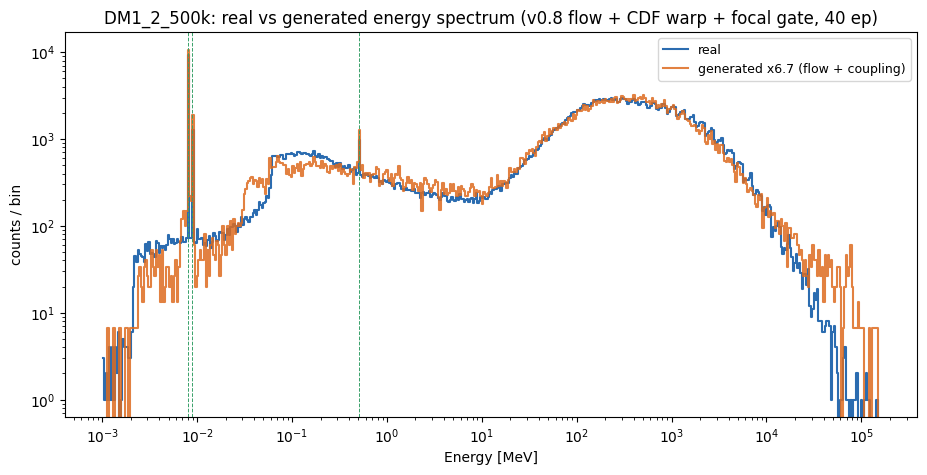

In [25]:
# ==========================================================
# Energy spectrum, real vs generated, on the detection binning.
# Log-log: this is the plot where the continuum shape (Compton edge, muon
# structure, low-energy tail) and the line spikes are both visible.
# ==========================================================

bins = np.asarray(feature_pack["energy_bins"])
real_counts, _ = np.histogram(E_real_full, bins=bins)
gen_counts, _ = np.histogram(E_gen, bins=bins)
scale = E_real_full.size / max(E_gen.size, 1)
centres = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots(figsize=(11, 5))
ax.step(centres, real_counts, where="mid", color="#2b6cb0", label="real")
ax.step(centres, gen_counts * scale, where="mid", color="#dd6b20", alpha=0.85,
        label=f"generated x{scale:.1f} (flow + coupling)")
for m in matched:
    ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=0.7, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("counts / bin")
ax.set_title(f"{SOURCE}: real vs generated energy spectrum "
             f"(v0.8 flow + CDF warp + focal gate, {globals().get('n_epochs_run', EPOCHS)} ep)")
ax.legend(fontsize=9)
fig.savefig(f"./Plots/v0_8_real_{SOURCE}_spectrum.png", dpi=140, bbox_inches="tight")
plt.show()

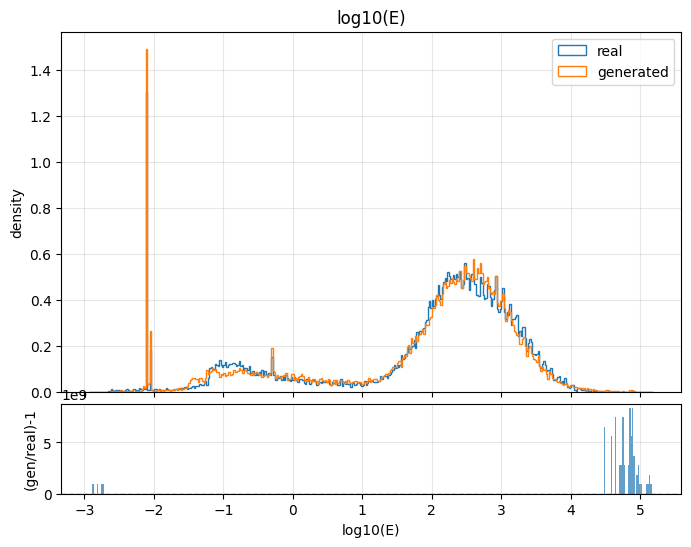

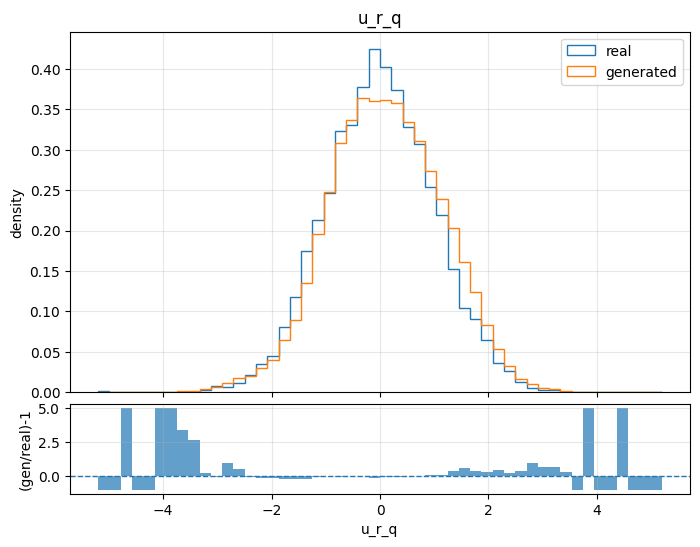

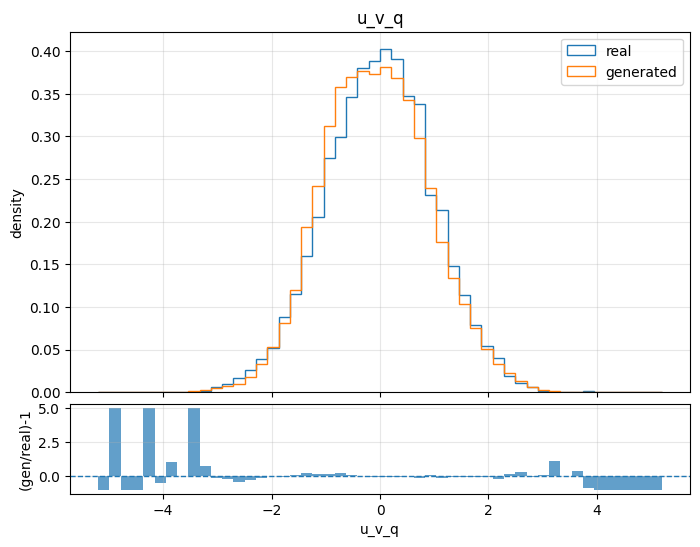

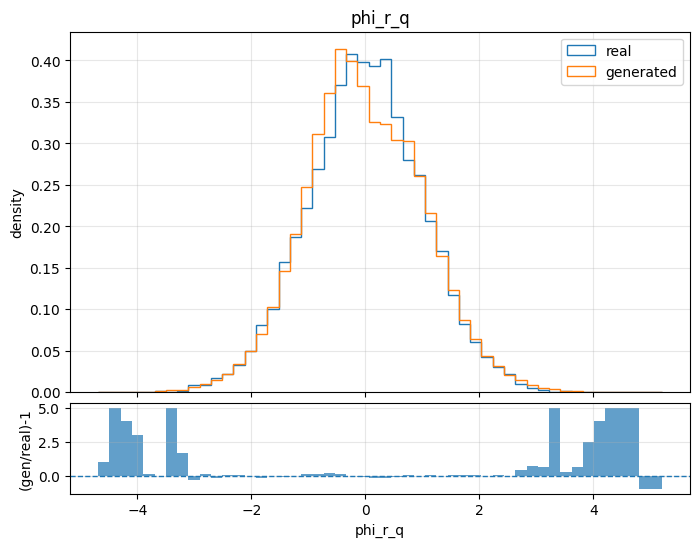

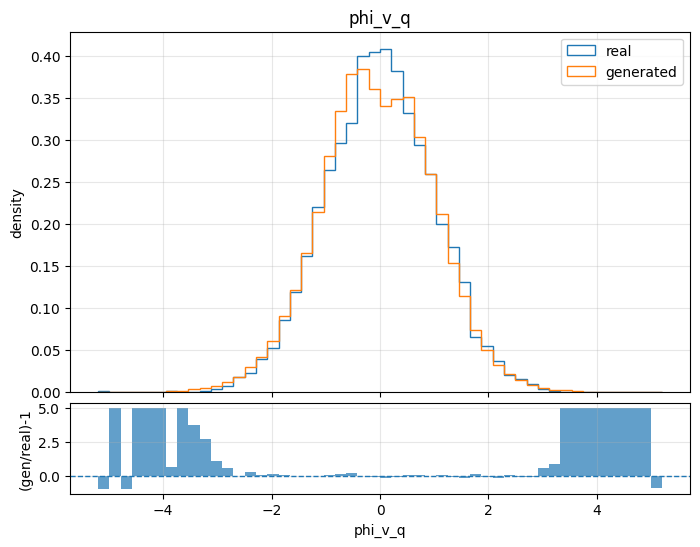

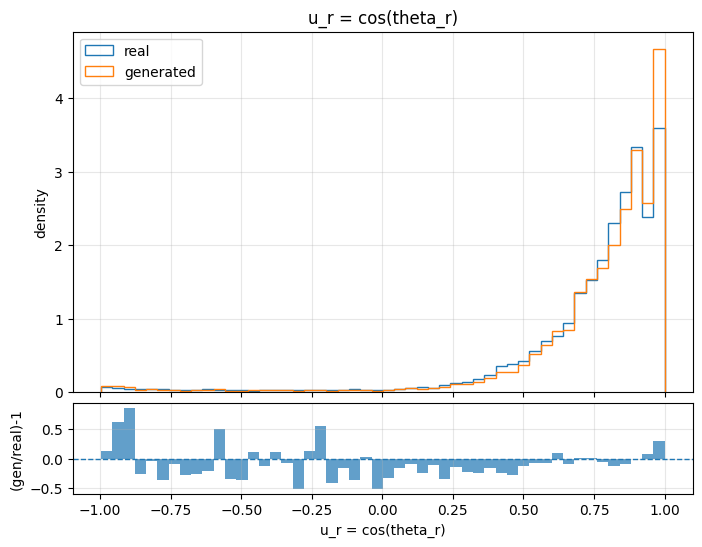

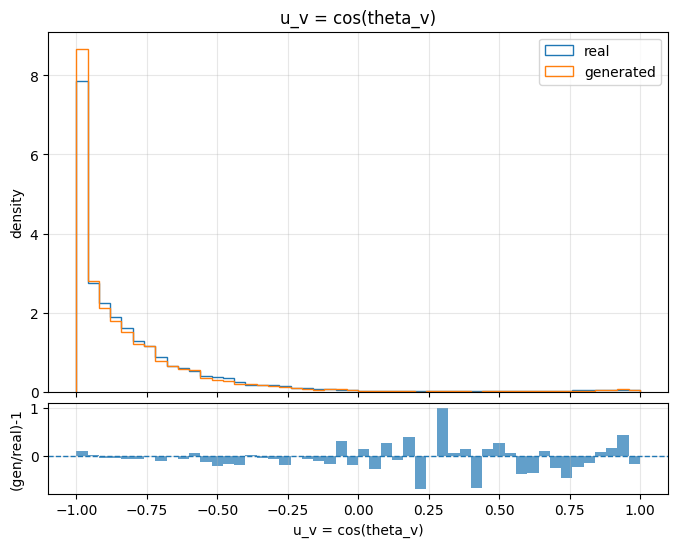

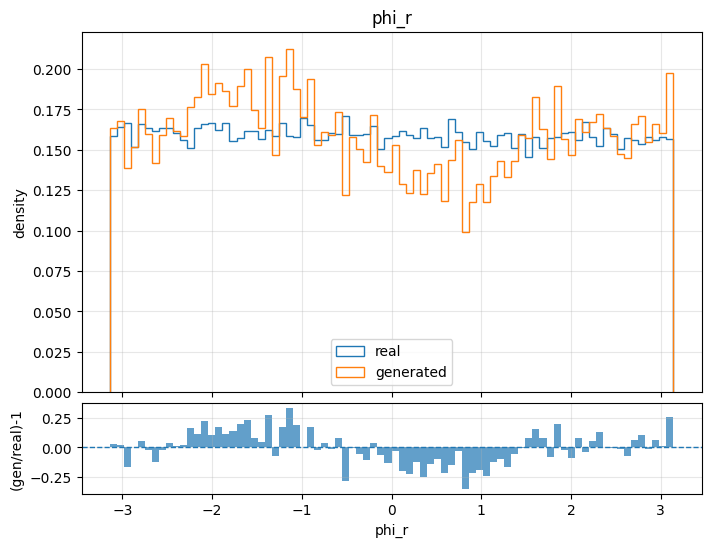

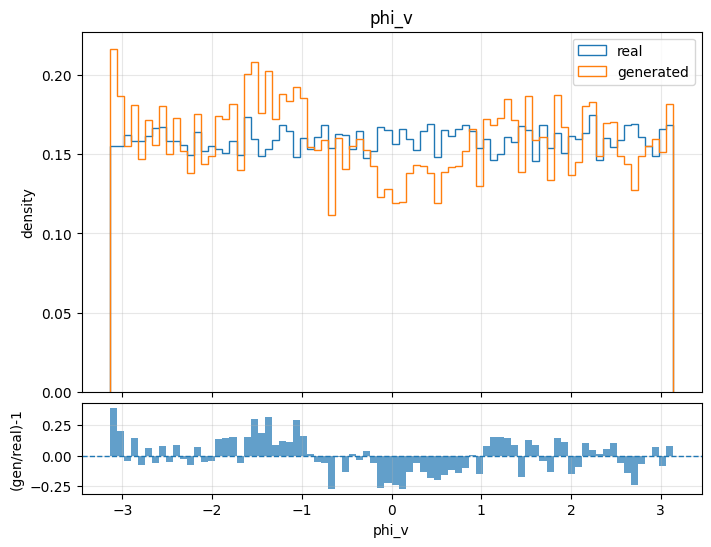

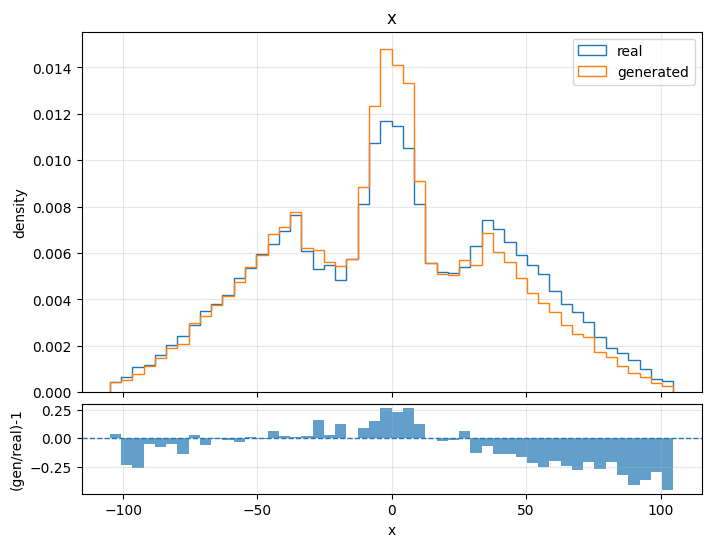

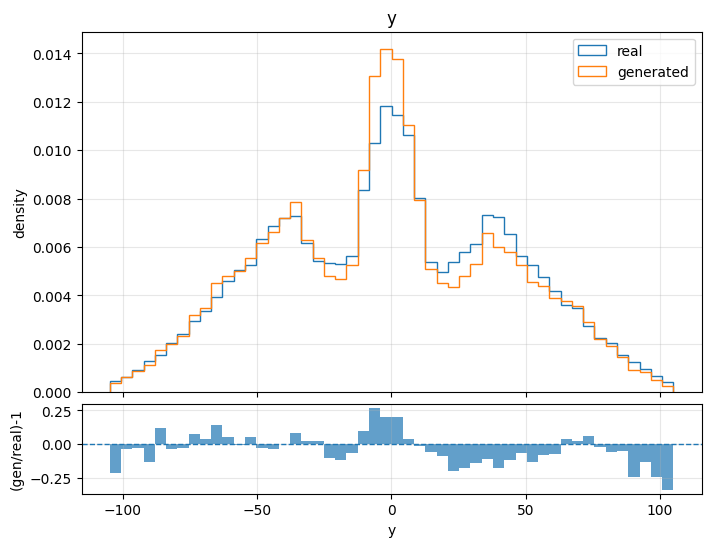

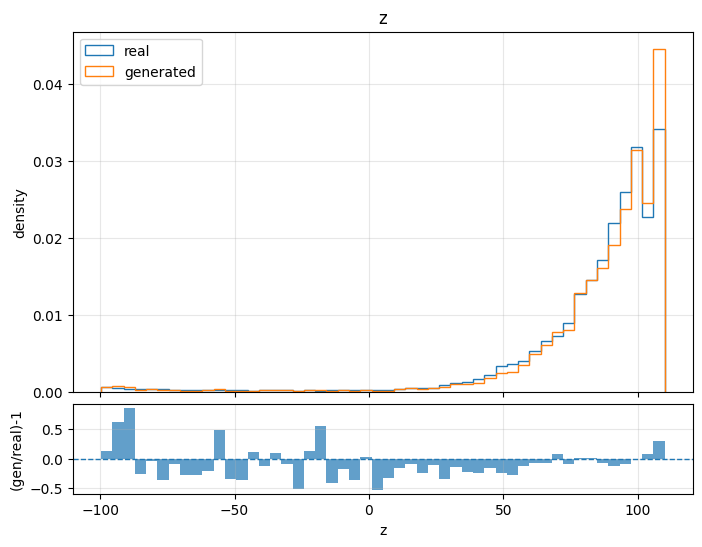

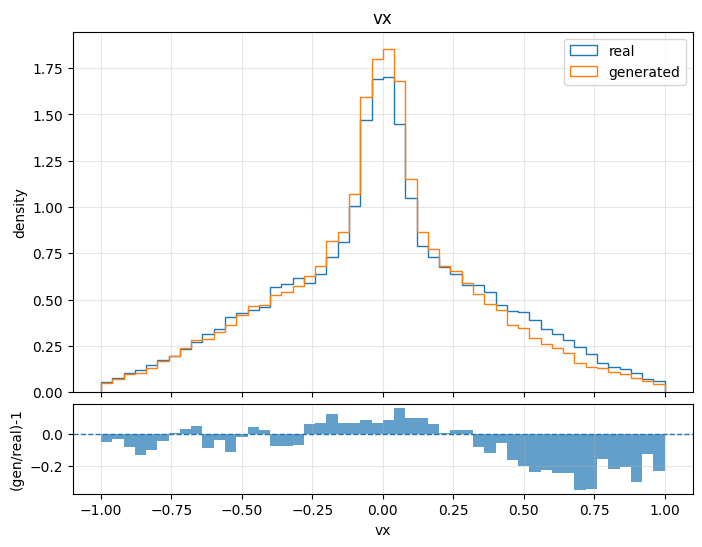

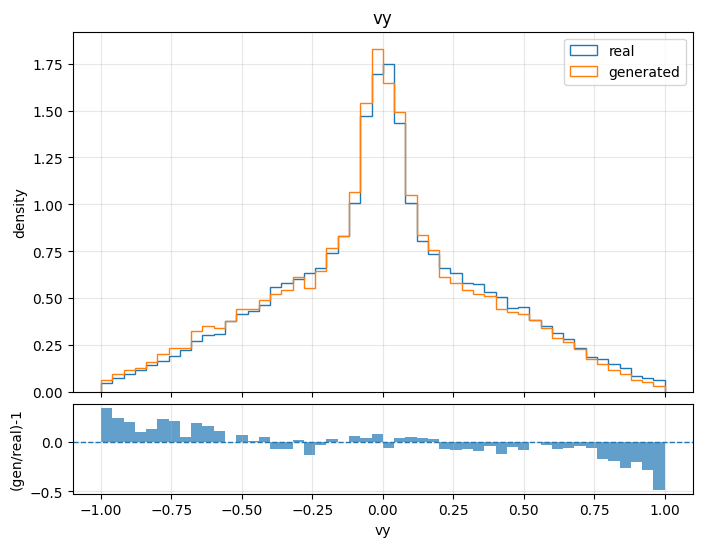

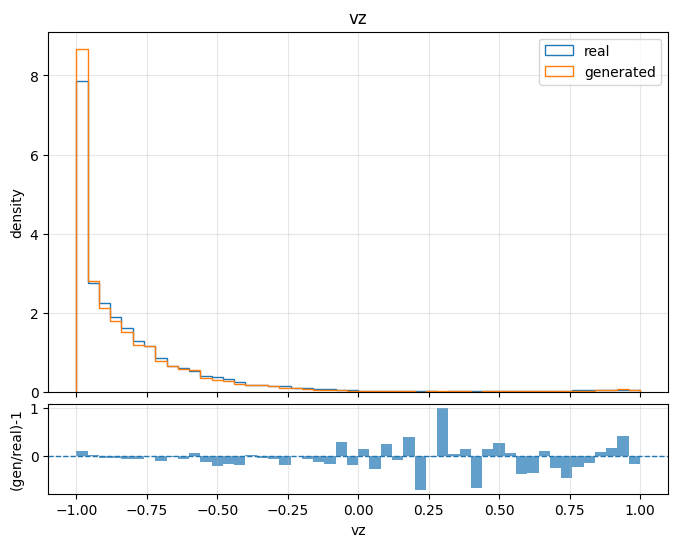


--- RANGE CHECK ---
logE real/gen: -2.9282799632089302 5.188039308395617 | -2.935321 5.1918187
u_v  real/gen: -0.9999989971370233 0.99992616254222 | -0.9999989799209196 0.9975363480739792

Position:
x real/gen: -104.97819005733714 104.77641971969686 | -104.90826195291048 104.75151900748119
y real/gen: -104.92847938051904 104.96244379584263 | -104.97301681502135 104.91902233556326
z real/gen: -99.68118900056501 109.9995741738522 | -99.68107897223736 109.99956511023021

Direction:
cphi_v real/gen: -0.9999996751280608 0.9999999987762282 | -0.9999996754250337 0.9999999544134154
sphi_v real/gen: -0.9999999988395813 0.9999999955753508 | -0.9999999999990435 0.999999967883016
vx real/gen: -0.9997206422643377 0.9995872113281398 | -0.999877297479925 0.9994040454346436
vy real/gen: -0.9996273968532873 0.9996004507140184 | -0.9997503530864198 0.9984632349679518
vz real/gen: -0.9999989971370233 0.99992616254222 | -0.9999989799199195 0.9975363480729866

--- COS/SIN NORM CHECK ---
phi_r real/gen: 0.

In [26]:
magi.set_plot_theme("light")

# ==========================================================
# Energy
# ==========================================================

magi.compare_hist_with_residuals(
    real_phys["logE_real"],
    gen_phys["logE_gen"],
    "log10(E)",
    bins=400,
    #savepath=f"./Plots/v0_8_energy_distribution_{SOURCE}.png",
    #dpi=300,
    show=True,
)

# ==========================================================
# Quantile-space variables, model native space
# ==========================================================

for key, label in [
    ("u_r_q", "u_r_q"),
    ("u_v_q", "u_v_q"),
    ("phi_r_q", "phi_r_q"),
    ("phi_v_q", "phi_v_q"),
]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Physical spherical variables
# ==========================================================

for key, label in [
    ("u_r", "u_r = cos(theta_r)"),
    ("u_v", "u_v = cos(theta_v)"),
]:
    plot_range = (
        min(real_phys[f"{key}_real"].min(), gen_phys[f"{key}_gen"].min()),
        max(real_phys[f"{key}_real"].max(), gen_phys[f"{key}_gen"].max()),
    )
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=plot_range,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Physical angular variables
# ==========================================================

for key, label in [("phi_r", "phi_r"), ("phi_v", "phi_v")]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=(-np.pi, np.pi),
        ratio_clip=5,
        bins=80,
    )

# ==========================================================
# Cartesian position and direction
# ==========================================================

for key in ["x", "y", "z"]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"], gen_phys[f"{key}_gen"], key, ratio_clip=5, bins=50,
    )

for key in ["vx", "vy", "vz"]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"], gen_phys[f"{key}_gen"], key,
        range_=(-1, 1), ratio_clip=5, bins=50,
    )

# ==========================================================
# Final reports
# ==========================================================

magi.report_final_ranges(real_phys, gen_phys)
magi.report_norm_checks(real_phys, gen_phys)

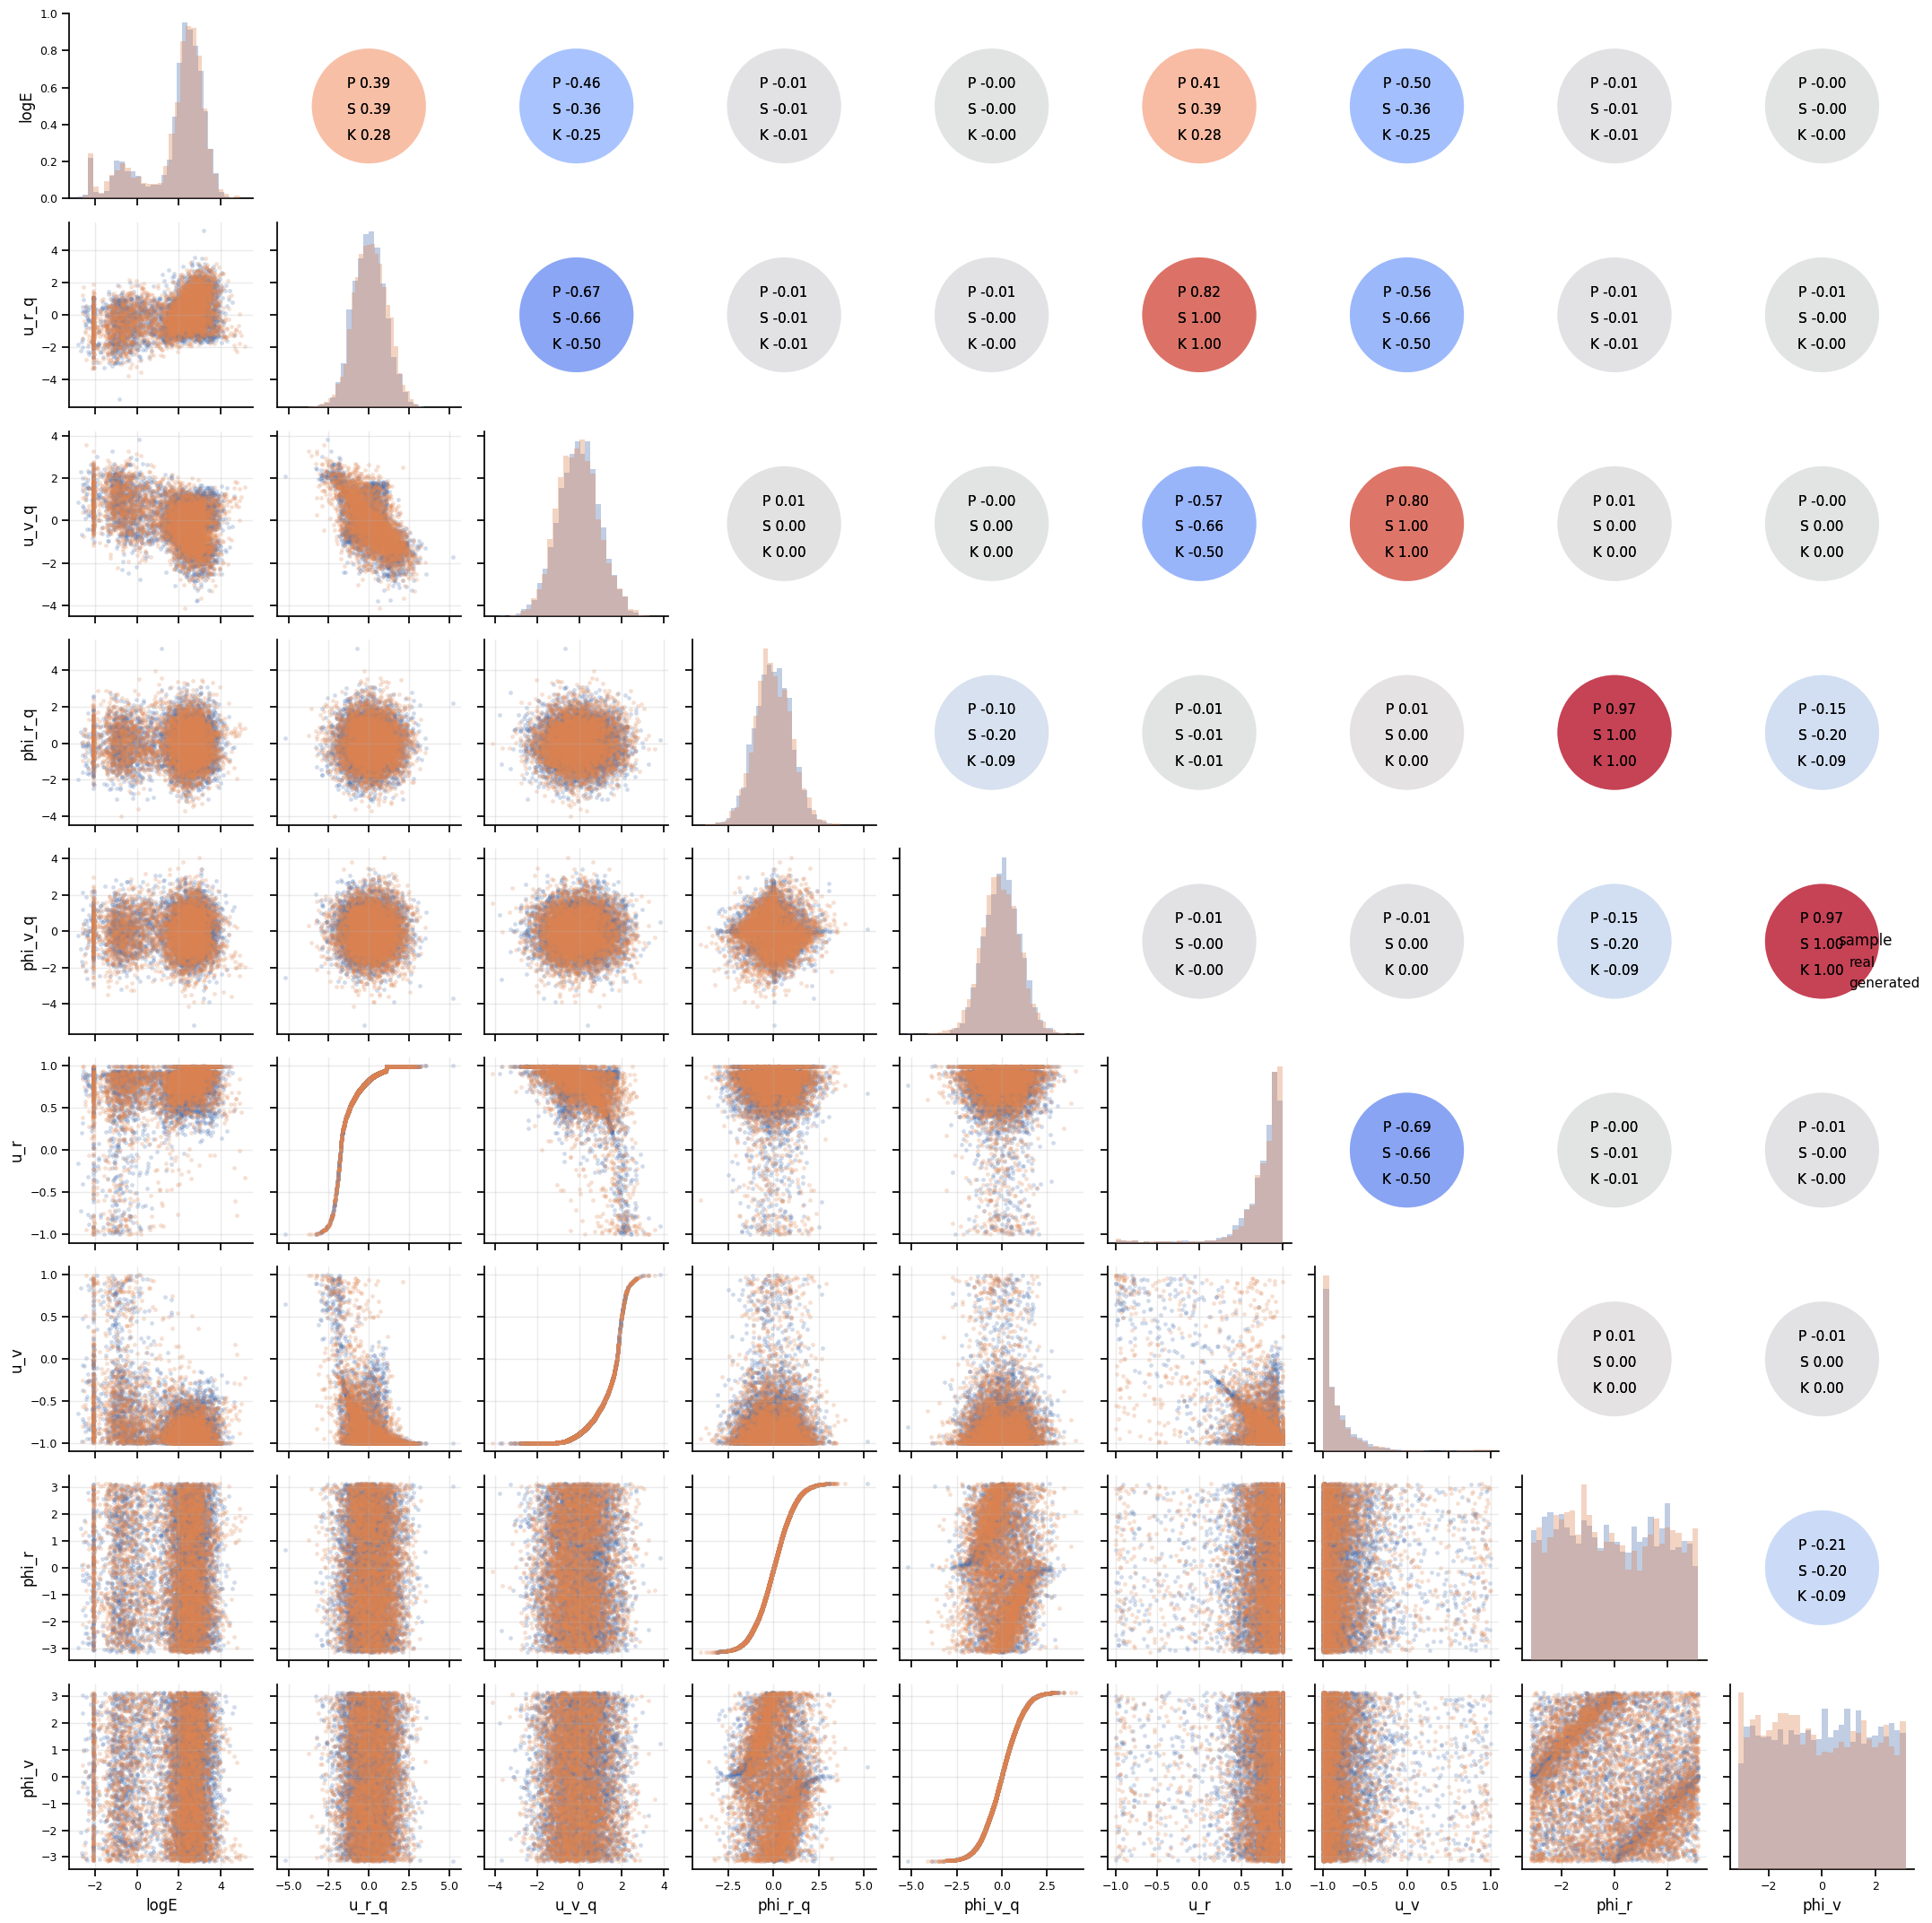

In [27]:
# ==========================================================
# Joint structure: pairgrid over model-native + physical variables
# ==========================================================

df_real_plot, df_gen_plot, df_compare = magi.build_real_generated_featureframes(
    real_phys,
    gen_phys,
)

corr_cols_compare = [
    "logE",
    "u_r_q", "u_v_q", "phi_r_q", "phi_v_q",
    "u_r", "u_v", "phi_r", "phi_v",
]

magi.plot_pairgrid_physics(
    df_compare,
    cols=corr_cols_compare,
    class_col="sample",
    sample_size=10000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
)

plt.show()

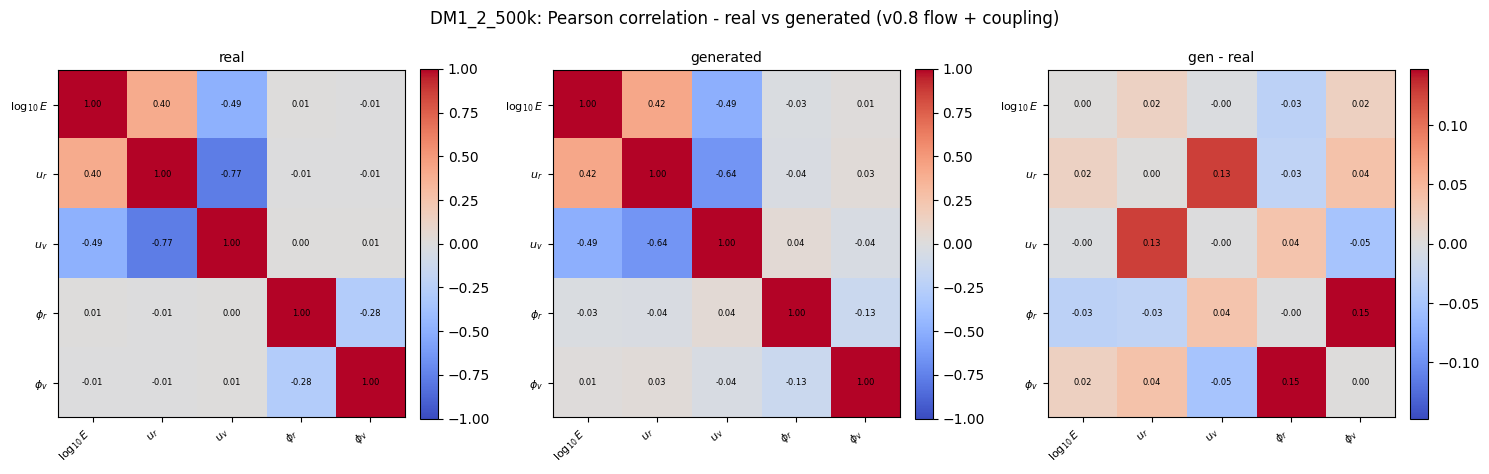

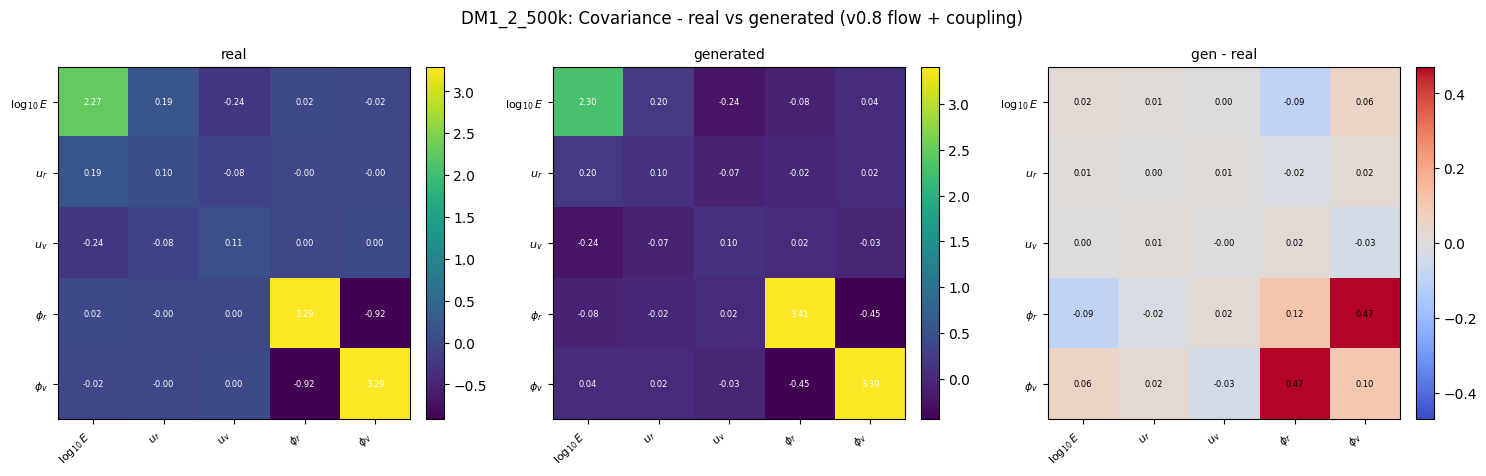

largest correlation residual: phi_r <-> phi_v  real -0.279 -> gen -0.131  (delta +0.148)


In [28]:
# ==========================================================
# Covariance / correlation triptychs: real | generated | (gen - real)
#
# This is the acceptance test for the learnable coupling prior. The number to
# watch is the energy<->geometry block: with prior="gaussian" the logE rows go
# flat at generation even though the model fits them in training (aggregated-
# posterior/prior mismatch). Target: every residual within +/-0.05.
# Same figures as tools/plot_v0_8_real_corr.py.
# ==========================================================

VARS = ["logE", "u_r", "u_v", "phi_r", "phi_v"]
LABELS = [r"$\log_{10}E$", r"$u_r$", r"$u_v$", r"$\phi_r$", r"$\phi_v$"]


def plot_matrix_triptych(df_real, df_gen, name, kind="corr", savepath=None):
    Xr = df_real[VARS].to_numpy()
    Xg = df_gen[VARS].to_numpy()

    if kind == "cov":
        Mr, Mg = np.cov(Xr, rowvar=False), np.cov(Xg, rowvar=False)
        cmap, title, vlim = "viridis", "Covariance", None
    else:
        Mr, Mg = np.corrcoef(Xr, rowvar=False), np.corrcoef(Xg, rowvar=False)
        cmap, title, vlim = "coolwarm", "Pearson correlation", (-1, 1)

    diff = Mg - Mr
    dmax = np.abs(diff).max() or 1.0

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    panels = [("real", Mr, cmap, vlim),
              ("generated", Mg, cmap, vlim),
              ("gen - real", diff, "coolwarm", (-dmax, dmax))]

    for ax, (ttl, M, cm, vl) in zip(axes, panels):
        kw = {} if vl is None else {"vmin": vl[0], "vmax": vl[1]}
        im = ax.imshow(M, cmap=cm, **kw)
        ax.set_xticks(range(len(VARS)))
        ax.set_xticklabels(LABELS, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(VARS)))
        ax.set_yticklabels(LABELS, fontsize=8)
        ax.set_title(ttl, fontsize=10)
        for a in range(len(VARS)):
            for b in range(len(VARS)):
                ax.text(b, a, f"{M[a, b]:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if cm == "viridis" else "black")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"{name}: {title} - real vs generated (v0.8 flow + coupling)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if savepath:
        fig.savefig(savepath, dpi=130, bbox_inches="tight")
    plt.show()
    return Mr, Mg


corr_r, corr_g = plot_matrix_triptych(
    df_real_plot, df_gen_plot, SOURCE, "corr",
    savepath=f"./Plots/v0_8_real_{SOURCE}_corr.png")

cov_r, cov_g = plot_matrix_triptych(
    df_real_plot, df_gen_plot, SOURCE, "cov",
    savepath=f"./Plots/v0_8_real_{SOURCE}_cov.png")

worst = np.abs(corr_g - corr_r)
i, j = np.unravel_index(np.argmax(worst), worst.shape)
print(f"largest correlation residual: {VARS[i]} <-> {VARS[j]}  "
      f"real {corr_r[i, j]:+.3f} -> gen {corr_g[i, j]:+.3f}  "
      f"(delta {corr_g[i, j] - corr_r[i, j]:+.3f})")

### Acceptance

The same thresholds `tools/acceptance_v0_8.py` applies to a checkpoint, so a
notebook run and an unattended run are graded identically:

| check | threshold |
|---|---|
| per-line recovery | 0.8 – 1.2 |
| near-line continuum ratio | 0.85 – 1.15 |
| Wasserstein on log10(E) | ≤ 0.05 |
| max coupling residual | ≤ 0.05 |

For the unattended equivalent over both sources:

```
python tools/acceptance_v0_8.py --sources CR Small --json logs/acceptance.json
```

## Saving Model

`model.to_generation_config()` is the important part: it captures everything the
loader needs to rebuild this exact architecture (line positions, continuum mode,
flow hyperparameters **and the CDF warp knots**, prior type, focal gamma, per-line
widths and their trainability). That is why the reload cell above only has to read
the JSON back instead of retyping a config dict like v0.7.2 did.

**Not re-saved.** This run loaded `trained_models/v0_8_2_DM1_2_500k/` rather than training a new model, so there is nothing new to save -- that directory already *is* this checkpoint.

In [29]:
magi.save_detector_table(
    gen_phys,
    filepath=f"./checkpoints/generated_particles/v0_8_2_{SOURCE}_generated.txt",
)

Saved detector table to: ./checkpoints/generated_particles/v0_8_2_DM1_2_500k_generated.txt
Rows saved: 52954
Columns: ['ParticleName', 'Energy', 'X', 'Y', 'Z', 'Vx', 'Vy', 'Vz']


,ParticleName,Energy,X,Y,Z,Vx,Vy,Vz
0,mu-,572.037598,3.318995,7.092794,109.707576,0.081605,0.021044,-0.996443
1,mu-,689.831421,-60.874670,-1.135067,90.545229,0.444908,0.010069,-0.895520
2,mu-,150.592896,49.512028,10.517571,96.994238,-0.292738,0.065591,-0.953940
3,mu-,321.079651,4.677619,9.743761,109.442228,0.064799,0.078112,-0.994836
4,mu-,189.254074,-45.033603,14.751868,98.698223,0.301569,-0.038734,-0.952657
...,...,...,...,...,...,...,...,...
52949,mu-,192.596405,-15.174954,42.112611,99.980254,-0.097387,-0.120685,-0.987902
52950,mu-,205.903717,20.435448,-35.515338,101.674987,-0.002854,0.476768,-0.879025
52951,mu-,559.273987,-36.359443,-26.431719,99.891280,0.175694,0.276535,-0.944807
52952,mu-,39.568398,-76.986601,33.577672,68.012723,0.310413,0.120601,-0.942920


## Visualizing the Trained Model

Two `magi.utils` functions write a self-contained, interactive HTML file for
looking inside this checkpoint -- open it in any browser, no server or
plotting library needed.

- **`save_routing_circuit`** reads only the saved config/metadata (no raw
  data, no loaded model): the gate's conditional routing per type, colored
  by `zone_probs` -- the same per-type distribution `prior_zone_conditioning`
  is conditioned on above.
- **`save_full_circuit`** shows the network's *aggregate usage* across many
  real held-out events per type - not just one - using Expected Conductance
  (Dhamdhere et al. 2019's generalization of Integrated Gradients to
  internal units, averaged over a pool of real baseline events per Erion et
  al. 2021's Expected Gradients, rather than an arbitrary zero vector). Every
  unit in every stage (encoder, latent `z`, decoder stem, deep trunk, and all
  three heads) is colored by its usage, and wires join the 10 most-used units
  of each stage to the next, each wire taking the color of its weaker end -- a
  link is only as used as its dimmer end. Both share one color scale
  (percentile rank across the whole network and every type), so parts of the
  network barely used by a type show up dim and heavily used parts show up
  bright, comparable across stages *and* across types. One button per particle
  type plus an "All types" button (usage pooled across every type) switches
  the view.
  It re-derives the held-out split from the raw detector table (line
  matching, gate targets, the quantile/log10 transforms), plus the Expected
  Conductance estimate itself (batched forward/backward passes per type) --
  budget several minutes per source total (~4 minutes measured for CR),
  longer for Torio's 8.8M events.

Both are plain HTML files - `show_circuit_html` below renders one inline in this notebook via a data-URI `IFrame`, so no separate browser tab is needed. A data URI (not `src=<path>`) is used because it works the same way regardless of how the notebook is served (classic, Lab, VS Code, Colab); the `IFrame` (not `IPython.display.HTML`) matters too - each widget defines top-level `const DATA`/`const LAYOUT`, so loading two copies into the same page would throw a redeclaration error the moment you display a second one.

In [30]:
import base64
from IPython.display import IFrame


def show_circuit_html(path, height=700):
    """Render a magi circuit-viz HTML file (save_routing_circuit /
    save_full_circuit output) inline in this notebook."""
    with open(path, "r") as f:
        html = f.read()
    data_uri = "data:text/html;base64," + base64.b64encode(html.encode("utf-8")).decode("ascii")
    return IFrame(src=data_uri, width="100%", height=height)

In [31]:
# ==========================================================
# Conditional routing circuit - per-type gate routing, from the
# checkpoint's own zone_probs (prior_zone_conditioning=True above).
# ==========================================================
show_circuit_html(
    magi.save_routing_circuit(save_dir=save_dir, model_name=model_name),
    height=650,
)

Saved routing circuit to: trained_models/v0_8_2_DM1_2_500k/mix_DM1_2_500k_routing_circuit.html


In [32]:
# ==========================================================
# Aggregate network-usage circuit - Expected Conductance per unit, per
# type (plus a pooled "All types" view), across many real held-out events.
# ==========================================================
show_circuit_html(
    magi.save_full_circuit(
        save_dir=save_dir, model_name=model_name,
        training_data_filepath=SOURCE_FILES[SOURCE],
        candidate_lines_file=CANDIDATE_LINES_FILE,
        center=center, radius=R, resolution_ev=X_IFU_RESOLUTION_EV,
    ),
    height=800,
)

Saved full circuit trace to: trained_models/v0_8_2_DM1_2_500k/mix_DM1_2_500k_full_circuit.html


# Generating Input Files for Geant4

`magi.generate_detector_table_to_file` now handles the v0.8 mixture energy head:
the fitted geometry transformers travel in `geometry_metadata` and the energy
transform in `energy_metadata` (`energy_head_mode="mixture"`,
`energy_transform="log10"` — the head emits `y = log10(E)`, so there are no
energy bins). The writer chunks generation to disk, drops neutrinos, and keeps
generating until `n_events` transportable particles have been written.

In [33]:
# Geant4-format export for the v0.8 mixture head.
# Columns: ParticleName Energy X Y Z Vx Vy Vz  (same schema as v0.7.2's export).
#
# geometry_metadata carries only JSON-safe descriptors, so it is merged with the
# fitted QuantileTransformer objects that reconstruction actually needs.

# magi.generate_detector_table_to_file(
#     model=model,
#     filepath=f"./generated/geant_input_v0_8_{SOURCE}_1M.txt",
#     n_events=1_000_000,
#     type_probs=type_probs,
#     n_types=n_types,
#     idx_to_type=idx_to_type,
#     # v0.8: no categorical energy bins - the mixture head returns y = log10(E)
#     energy_bins=None,
#     energy_metadata={
#         "energy_head_mode": "mixture",
#         "energy_transform": "log10",
#     },
#     geometry_metadata={**geometry_metadata, **quantile_transformers},
#     center=center,
#     radius=R,
#     chunk_size=100_000,
#     output_format="text",
# )

In [34]:
# Read back and eyeball the exported file
# cols_no_event_id = ["ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"]
# test_df = magi.load_detector_table(
#     f"./generated/geant_input_v0_8_{SOURCE}_1M.txt",
#     columns=cols_no_event_id,
#     drop_event_id=False,
# )
# test_df.head()

## Notes on this run

**Configuration.** Flow continuum (24 bins, 3 transforms) + CDF pre-warp; fixed
lines pinned to 4 eV FWHM at **EADL** energies; `energy_flow_condition="z_cond"`;
`prior="coupling"` with **`prior_zone_conditioning=True`** (v0.8.2); gate targets
with a **resolution** bandwidth (`"exact"` tried and rejected, see below);
`w_gate_aux=2.0`, `gate_focal_gamma=1.0`; 40 epochs on CPU (~48 min CR, ~33 min
Small).

**What v0.8.2 changed, and what it did not touch.** Prior zone-conditioning is
the one confirmed improvement: on CR, 3 seeds, it took Al Kα1 from
0.702 ± 0.290 (FAIL) to 0.959 ± 0.025 (PASS) with coupling unaffected
(0.0345 ± 0.0048 → 0.0285 ± 0.0101). Everything else inherited from v0.8.1 —
EADL line positions, resolution-bandwidth gate targets, `gate_focal_gamma=1` —
is unchanged.

**Rejected: `bandwidth_mode="exact"`.** Raw Geant4 crossing data has no
detector response applied, so fluorescence lines really are exactly
monoenergetic (verified: 7,542 Cu Kα1 events at one identical float64 energy
in CR). That physics is correct, and it suggested labelling gate targets by
exact match instead of a Gaussian kernel of the detector resolution. Measured
on CR it did not fix the line it targeted (Cu Kα1 routing 2.011 vs. the
confirmed 2.052 — no change), it broke the confirmed Al Kα1 result (→ 0.578),
and it pushed the coupling residual outside its bar (→ 0.054). The soft
resolution kernel appears to regularize the gate in a way a hard 0/1 target
does not. Full account: `docs/v0.8.1_line_truth.md` §14.2. Do not re-try
without new information.

**This run.** `SOURCE = "DM1_2_500k"` -- the DM1.2 laboratory-cryostat mass model, a different geometry (centre (0,0,5) mm, R=105 mm) and a different candidate-line table (own GDML, escape peaks) from the SRON CR/Small/Torio sources the architecture notes above were measured on. This checkpoint is the one shipped in `trained_models/v0_8_2_DM1_2_500k/`, loaded rather than retrained live here.

**This run.** If `SOURCE = "Small"`, this is the **first v0.8.2 measurement**
on this source — Phase C's 3-seed confirmation above was CR-only. Compare this
checkpoint's acceptance report against the v0.8.1 Small baseline
(`trained_models/v0_8_1_Small`) before treating any Small-specific number as
confirmed.

**Still open.**
- Per-line `gate_class_weights`, if the acceptance report still shows a
  heterogeneous per-line gap — with a two-sided clip. Already tried once on CR
  with no effect distinguishable from noise (`docs/v0.8.1_line_truth.md` §10).
- CR's low-energy Compton edge is still slightly rounded; a CDF-warp knot boost
  and `continuum_flow_bins` 24→32 were tried together and **regressed** every
  CR band (§11) — if retried, vary the two levers separately.
- An intermittent optimizer crash during `fit` — `Incompatible shapes: [N] vs.
  [0]` inside Adam's `apply_gradients`, not reproduced deterministically, root
  cause not identified. See `docs/v0.8.1_line_truth.md` §15. If `fit` fails
  with a shape mismatch below, just re-run the cell.
- Multi-seed error bars for whatever source this notebook is run on beyond
  seed 42 — use `tools/run_v0_8_real.py --seed <7|13>` and
  `tools/acceptance_v0_8.py --seeds 42 7 13`.
- The defaults flip (making `continuum_mode="flow"`, `prior="coupling"`,
  `prior_zone_conditioning=True` etc. the constructor defaults) is gated
  behind the go/no-go.

**Escape peaks.** Requested and implemented as candidates
(`--escape-peaks` in `tools/build_candidate_lines_from_geant4.py`, derived from the
detector volumes' materials in the GDML: Au absorber, Si plate and CryoAC, Ge
thermistor, Cu clamps). All 358 candidates were audited against the real spectra and
**none is present** — expected, since this training data is the spectrum of particles
*crossing* a virtual sphere, not energy *deposited* in the detector, and an escape
peak is a deposited-energy artifact. The escaping fluorescence photon appears in this
data as its own line, which is already modelled. Documented as a null result in
`docs/v0.8.1_line_truth.md` §5.

## Appendix — Flow vs Gaussian continuum (synthetic demonstration)

This section is a **self-contained synthetic demo** of the v0.8 energy head's
continuum term. It reproduces CryoSphere-Small's pathology (a single sharp
continuum peak + a sparse low-energy tail + two closely-spaced lines) and
trains the **same** model twice, changing only the continuum:

- `continuum_mode="gaussian"` — the K=1 parametric-Gaussian continuum baseline.
- `continuum_mode="flow"` — the conditional rational-quadratic-spline flow
  continuum (`core/flows.py`), here with `energy_flow_condition="cond"` and the
  line width pinned to the injected resolution.

The plot below overlays the real spectrum (grey) with each model's generated
spectrum. The Gaussian continuum cannot be both sharp at the peak and near-zero
in the empty high-energy region, so it smears into a broad hump; the flow
tracks the real shape across the peak, the sparse tail, the line spike, and the
empty high-E cutoff.

**Caveat (important):** this demo uses *noise* geometry, so it isolates the
continuum-shape question and does **not** exercise the energy<->geometry
coupling. On real data the energy head must condition on the latent `z`
(`energy_flow_condition="z_cond"`, as in the training section above) to keep that
coupling — which re-introduces the aggregated-posterior/prior mismatch and needs
the **learnable prior** before generation is faithful. See
`docs/v0.8_learnable_prior_plan.md`. So: this figure demonstrates the flow's
continuum *shape capacity*, not a finished real-data result.

The full stress tests that gate each development cycle live in
`tools/synthetic_stress_test_small_singlepeak.py` (single peak, `--sparse-tail`)
and `tools/synthetic_stress_test_cr_multimodal.py` (multimodal + rare line
cluster, `--gate-focal-gamma`).

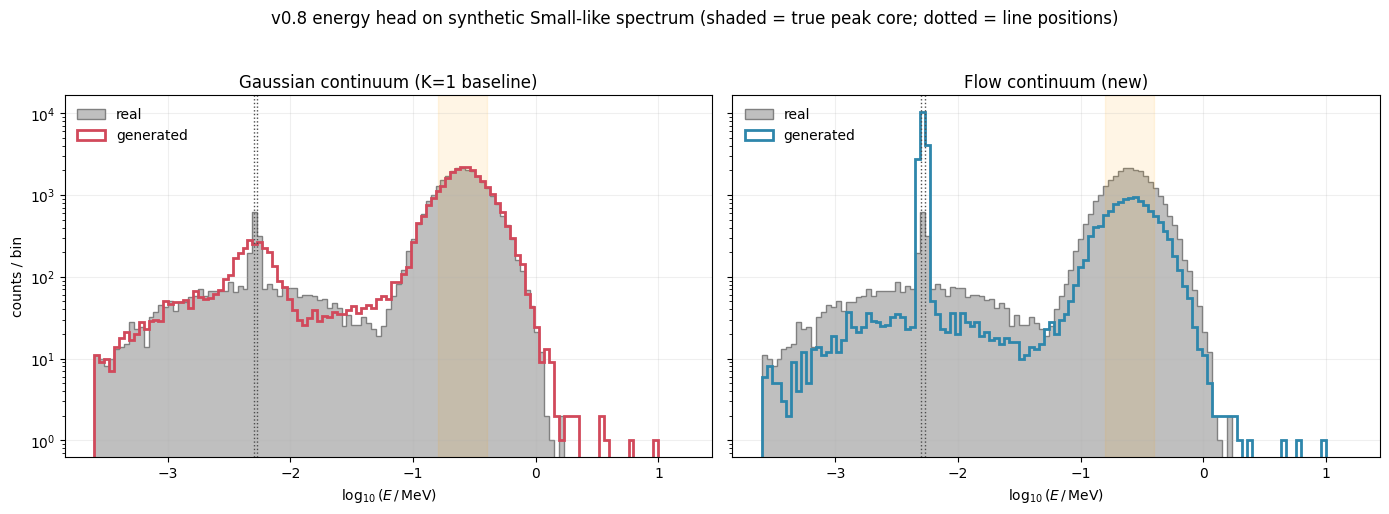

In [35]:
# Self-contained synthetic demo (no real data needed). Curtailed to EPOCHS=30
# for the full-notebook run (it is an illustrative appendix, not the real
# result); raise it for a cleaner figure.
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
import magi

EPOCHS_DEMO = 30
rng = np.random.default_rng(42)

# --- synthetic Small-like spectrum: sharp peak + sparse tail + 2 close lines
N_TOTAL, LINE_FRAC, N_LINES_DEMO = 30_000, 0.03, 2
cont_w = np.array([0.90, 0.10]); cont_w = cont_w / cont_w.sum() * (1 - LINE_FRAC)
n_lines = int(round(N_TOTAL * LINE_FRAC)); n_cont = N_TOTAL - n_lines
n_peak = int(round(n_cont * cont_w[0] / (1 - LINE_FRAC))); n_tail = n_cont - n_peak
E_peak = 10.0 ** rng.normal(-0.60, 0.20, n_peak)
E_tail = 10.0 ** rng.normal(-2.30, 0.60, n_tail)
line_y = np.array([-2.30, -2.268]); line_mev = 10.0 ** line_y; sig_y = 0.015
per = [n_lines // N_LINES_DEMO] * (N_LINES_DEMO - 1) + [n_lines - (n_lines // N_LINES_DEMO) * (N_LINES_DEMO - 1)]
E_lines = np.concatenate([10.0 ** rng.normal(y0, sig_y, k) for y0, k in zip(line_y, per)])
E_demo = np.concatenate([E_peak, E_tail, E_lines]); rng.shuffle(E_demo)

bins_demo = magi.build_energy_bins(E_demo, mode="log_fixed_count", n_bins=256, min_counts=20)
matched_demo = [{"label": f"line_{i}", "origin": "synthetic",
                 "candidate_energy_mev": float(e), "count": int(c)}
                for i, (e, c) in enumerate(zip(line_mev, per))]
gate_t = magi.build_gate_targets(E_demo, bins_demo, matched_demo)
energy_y_demo = np.log10(E_demo).astype(np.float32); n = E_demo.size
noise = lambda: rng.normal(0, 1, n).astype(np.float32)
y_cont = np.concatenate([noise()[:, None], noise()[:, None], noise()[:, None],
                         noise()[:, None], energy_y_demo[:, None], gate_t.astype(np.float32)], 1)
cond_demo = np.ones((n, 1), np.float32)
ds = tf.data.Dataset.from_tensor_slices(
        ((y_cont, np.zeros(n, np.int32), cond_demo), np.zeros((n, 1), np.float32))
     ).shuffle(n, seed=42).batch(512)

def train_and_gen(**extra):
    m = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
            n_types=1, line_positions_y=line_y.astype(np.float32),
            latent_dim=8, hidden=(128, 128, 64), beta=0.2, **extra)
    magi.compile_model(m, learning_rate=2e-4)
    m.fit(ds, epochs=EPOCHS_DEMO, verbose=0)
    return 10.0 ** m.generate(tf.constant(cond_demo), n)["energy_y"].numpy()

E_gauss = train_and_gen()
E_flow  = train_and_gen(continuum_mode="flow", energy_flow_condition="cond",
                        continuum_flow_y_mean=float(energy_y_demo.mean()),
                        continuum_flow_y_scale=float(energy_y_demo.std()),
                        line_logsigma_init=float(np.log(sig_y)),
                        line_logsigma_trainable=False)

# --- plot
hb = np.linspace(-3.6, 1.2, 120); rl = np.log10(E_demo)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True, sharey=True)
for a, Eg, ttl, c in [(ax[0], E_gauss, "Gaussian continuum (K=1 baseline)", "#d1495b"),
                      (ax[1], E_flow, "Flow continuum (new)", "#2e86ab")]:
    a.hist(rl, hb, histtype="stepfilled", color="0.75", edgecolor="0.5", label="real", log=True)
    a.hist(np.log10(Eg), hb, histtype="step", color=c, lw=2, label="generated", log=True)
    for ly in line_y: a.axvline(ly, color="0.3", ls=":", lw=1)
    a.axvspan(-0.8, -0.4, color="orange", alpha=0.10)
    a.set_title(ttl); a.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{MeV})$")
    a.legend(loc="upper left", frameon=False); a.grid(alpha=0.2)
ax[0].set_ylabel("counts / bin")
fig.suptitle("v0.8 energy head on synthetic Small-like spectrum "
             "(shaded = true peak core; dotted = line positions)")
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()